# Импорт библиотек и загрузка данных через API

Для работы я использую индекс **IMOEX**.  
Исторические данные загружаю через **Tinkoff Invest API**.

Загружаю часовые свечи за пятилетний период.  
Данные загружаются частями, чтобы избежать ошибок API на больших интервалах за один запрос.

In [1]:
!pip install -q --no-deps git+https://github.com/RussianInvestments/invest-python.git@0.2.0-beta97
!pip install -q arch
!pip install -q tensorflow

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from datetime import datetime, timedelta, timezone

from tinkoff.invest import Client
from tinkoff.invest import CandleInterval

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

In [3]:
TOKEN = "t.BLF917dBA7MHUl8njwXDoIbU187ZFTcxJNrVDZeDMGEQHyLNRW_ie_Hjj6ZmtQdtauA07Pzt8xbX0hK5w5HR-g"

with Client(TOKEN) as client:
    search_result = client.instruments.find_instrument(query="IMOEX")

for item in search_result.instruments:
    print("name:", item.name)
    print("ticker:", item.ticker)
    print("figi:", item.figi)
    print("uid:", item.uid)
    print("class_code:", item.class_code)
    print("instrument_type:", item.instrument_type)
    print("-" * 50)

name: Индекс МосБиржи (доп. сессия)
ticker: IMOEX2
figi: BBG00KDWPPW3
uid: 83ef5122-e41e-4cf4-bbe4-b11a2b3f953e
class_code: TQBR
instrument_type: index
--------------------------------------------------
name: IMOEXF Индекс МосБиржи
ticker: IMOEXF
figi: FUTIMOEXF000
uid: 5bcff194-f10d-4314-b9ee-56b7fdb344fd
class_code: SPBFUT
instrument_type: futures
--------------------------------------------------
name: Индекс МосБиржи
ticker: IMOEX
figi: BBG00KDWPPW2
uid: 4821c9aa-36e8-4743-b37c-861e58581b25
class_code: TQBR
instrument_type: index
--------------------------------------------------


In [4]:
IMOEX_UID = "4821c9aa-36e8-4743-b37c-861e58581b25"

In [5]:
def money_to_float(m):
    return m.units + m.nano / 1e9

In [6]:
def load_hourly_candles(token, instrument_uid, days_back=365*5, chunk_days=60, pause=0.2):
    """
    Загрузка часовых свечей через UID.

    Параметры:
    token - токен Tinkoff API
    instrument_uid - UID инструмента
    days_back - сколько дней назад грузить историю
    chunk_days - размер одного куска загрузки в днях
    pause - пауза между запросами

    Возвращает:
    pandas DataFrame
    """

    now = datetime.now(timezone.utc)
    date_from = now - timedelta(days=days_back)

    rows = []
    left = date_from

    with Client(token) as client:
        while left < now:
            right = min(left + timedelta(days=chunk_days), now)

            print(f"Гружу данные с {left.strftime('%Y-%m-%d')} по {right.strftime('%Y-%m-%d')}")

            try:
                candles = client.market_data.get_candles(
                    instrument_id=instrument_uid,
                    from_=left,
                    to=right,
                    interval=CandleInterval.CANDLE_INTERVAL_HOUR)

                for c in candles.candles:
                    rows.append({
                        "date": c.time,
                        "open": money_to_float(c.open),
                        "high": money_to_float(c.high),
                        "low": money_to_float(c.low),
                        "close": money_to_float(c.close),
                        "volume": c.volume})

            except RequestError as e:
                print("Ошибка на куске:")
                print(f"Период: {left} - {right}")
                print(e)

            left = right
            time.sleep(pause)

    df = pd.DataFrame(rows)

    if len(df) == 0:
        print("Данные не загрузились")
        return df


    df = df.drop_duplicates(subset=["date"]).sort_values("date").reset_index(drop=True)
    df["date"] = pd.to_datetime(df["date"]).dt.tz_localize(None)
    return df

In [7]:
df = load_hourly_candles(
    token=TOKEN,
    instrument_uid=IMOEX_UID,
    days_back=365*5,
    chunk_days=60)

print("\nРазмер таблицы:", df.shape)
df.head()

Гружу данные с 2021-03-30 по 2021-05-29
Гружу данные с 2021-05-29 по 2021-07-28
Гружу данные с 2021-07-28 по 2021-09-26
Гружу данные с 2021-09-26 по 2021-11-25
Гружу данные с 2021-11-25 по 2022-01-24
Гружу данные с 2022-01-24 по 2022-03-25
Гружу данные с 2022-03-25 по 2022-05-24
Гружу данные с 2022-05-24 по 2022-07-23
Гружу данные с 2022-07-23 по 2022-09-21
Гружу данные с 2022-09-21 по 2022-11-20
Гружу данные с 2022-11-20 по 2023-01-19
Гружу данные с 2023-01-19 по 2023-03-20
Гружу данные с 2023-03-20 по 2023-05-19
Гружу данные с 2023-05-19 по 2023-07-18
Гружу данные с 2023-07-18 по 2023-09-16
Гружу данные с 2023-09-16 по 2023-11-15
Гружу данные с 2023-11-15 по 2024-01-14
Гружу данные с 2024-01-14 по 2024-03-14
Гружу данные с 2024-03-14 по 2024-05-13
Гружу данные с 2024-05-13 по 2024-07-12
Гружу данные с 2024-07-12 по 2024-09-10
Гружу данные с 2024-09-10 по 2024-11-09
Гружу данные с 2024-11-09 по 2025-01-08
Гружу данные с 2025-01-08 по 2025-03-09
Гружу данные с 2025-03-09 по 2025-05-08


,date,open,high,low,close,volume
0,2021-03-30 13:00:00,3518.87,3520.70,3512.76,3516.24,0
1,2021-03-30 14:00:00,3516.23,3518.18,3507.40,3511.98,0
2,2021-03-30 15:00:00,3512.19,3525.23,3512.19,3525.23,0
3,2021-03-31 07:00:00,3525.56,3529.76,3516.17,3520.32,0
4,2021-03-31 08:00:00,3520.48,3522.11,3511.31,3519.20,0


# Первичная проверка и очистка данных
Чтобы убедиться, что данные корректно загрузились и подходят для дальнейшего расчета доходностей, волатильности и признаков для моделей проверяю:

- типы столбцов;
- наличие пропусков;
- минимальную и максимальную даты;
- число наблюдений;
- наличие дубликатов;
- общий вид временного ряда.

In [8]:
print("\nТипы данных:")
print(df.dtypes)

print("\nПропуски:")
print(df.isna().sum())

print("\nМинимальная дата:", df["date"].min())
print("Максимальная дата:", df["date"].max())
print("Число наблюдений:", len(df))

print("\nДубликаты по date:", df["date"].duplicated().sum())


Типы данных:
date      datetime64[ns]
open             float64
high             float64
low              float64
close            float64
volume             int64
dtype: object

Пропуски:
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

Минимальная дата: 2021-03-30 13:00:00
Максимальная дата: 2026-03-27 16:00:00
Число наблюдений: 11603

Дубликаты по date: 0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11603 entries, 0 to 11602
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    11603 non-null  datetime64[ns]
 1   open    11603 non-null  float64       
 2   high    11603 non-null  float64       
 3   low     11603 non-null  float64       
 4   close   11603 non-null  float64       
 5   volume  11603 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 544.0 KB


In [10]:
df = df.drop_duplicates(subset=["date"]).sort_values("date").reset_index(drop=True)
df = df.set_index("date").copy()
df.head()

,open,high,low,close,volume
date,,,,,
2021-03-30 13:00:00,3518.87,3520.70,3512.76,3516.24,0
2021-03-30 14:00:00,3516.23,3518.18,3507.40,3511.98,0
2021-03-30 15:00:00,3512.19,3525.23,3512.19,3525.23,0
2021-03-31 07:00:00,3525.56,3529.76,3516.17,3520.32,0
2021-03-31 08:00:00,3520.48,3522.11,3511.31,3519.20,0


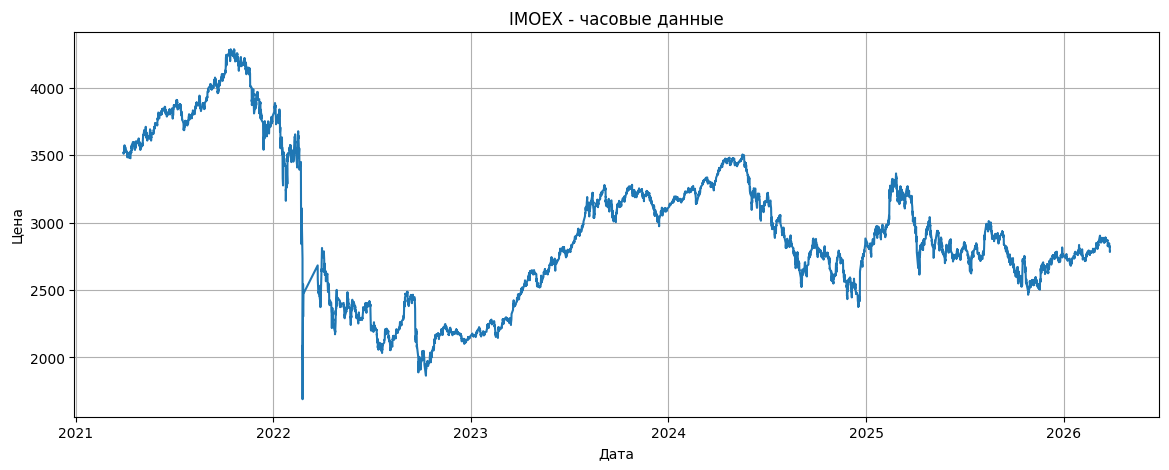

In [11]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["close"])
plt.title("IMOEX - часовые данные")
plt.xlabel("Дата")
plt.ylabel("Цена")
plt.grid(True)
plt.show()

In [12]:
time_diff = df.index.to_series().diff().value_counts().head(10)
time_diff

,count
date,
0 days 01:00:00,10344
0 days 16:00:00,700
0 days 15:00:00,268
2 days 16:00:00,170
2 days 15:00:00,66
1 days 16:00:00,10
3 days 16:00:00,9
1 days 15:00:00,6
0 days 14:00:00,5


In [13]:
df_imoex = df.copy()
print(df_imoex.shape)
df_imoex.head()

(11603, 5)


,open,high,low,close,volume
date,,,,,
2021-03-30 13:00:00,3518.87,3520.70,3512.76,3516.24,0
2021-03-30 14:00:00,3516.23,3518.18,3507.40,3511.98,0
2021-03-30 15:00:00,3512.19,3525.23,3512.19,3525.23,0
2021-03-31 07:00:00,3525.56,3529.76,3516.17,3520.32,0
2021-03-31 08:00:00,3520.48,3522.11,3511.31,3519.20,0


# Feature engineering

Для прогнозирования волатильности признаки строю на основе на прошлой информации, чтобы избежать утечки данных.

В качестве признаков беру несколько групп:

- доходности на разных горизонтах;
- абсолютные доходности;
- диапазон свечи и внутрисвечное изменение;
- скользящую волатильность;
- реализованная волатильность на прошлых окнах;
- скользящие средние цены;
- отклонение цены от скользящих средних;
- лаги ключевых признаков;
- календарные признаки.

In [14]:
feat_df = df.copy()

#Базовые доходности
feat_df["return_1h"] = feat_df["close"].pct_change()
feat_df["log_return_1h"] = np.log(feat_df["close"] / feat_df["close"].shift(1))
feat_df["abs_return_1h"] = feat_df["log_return_1h"].abs()

#Доходности на нескольких горизонтах
feat_df["log_return_3h"] = np.log(feat_df["close"] / feat_df["close"].shift(3))
feat_df["log_return_6h"] = np.log(feat_df["close"] / feat_df["close"].shift(6))
feat_df["log_return_12h"] = np.log(feat_df["close"] / feat_df["close"].shift(12))
feat_df["log_return_24h"] = np.log(feat_df["close"] / feat_df["close"].shift(24))

#Признаки по свече
feat_df["hl_range"] = (feat_df["high"] - feat_df["low"]) / feat_df["close"]
feat_df["co_change"] = (feat_df["close"] - feat_df["open"]) / feat_df["open"]

#Скользящая волатильность
feat_df["rolling_std_6"] = feat_df["log_return_1h"].rolling(6).std()
feat_df["rolling_std_12"] = feat_df["log_return_1h"].rolling(12).std()
feat_df["rolling_std_24"] = feat_df["log_return_1h"].rolling(24).std()
feat_df["rolling_std_72"] = feat_df["log_return_1h"].rolling(72).std()

#Скользящие средние по модулю доходности
feat_df["rolling_absret_mean_6"] = feat_df["abs_return_1h"].rolling(6).mean()
feat_df["rolling_absret_mean_24"] = feat_df["abs_return_1h"].rolling(24).mean()
feat_df["rolling_absret_mean_72"] = feat_df["abs_return_1h"].rolling(72).mean()

#Реализованная волатильность на прошлых окнах
feat_df["rv_6"] = np.sqrt((feat_df["log_return_1h"] ** 2).rolling(6).sum())
feat_df["rv_24"] = np.sqrt((feat_df["log_return_1h"] ** 2).rolling(24).sum())
feat_df["rv_72"] = np.sqrt((feat_df["log_return_1h"] ** 2).rolling(72).sum())

#Скользящие средние цены
feat_df["ma_6"] = feat_df["close"].rolling(6).mean()
feat_df["ma_24"] = feat_df["close"].rolling(24).mean()
feat_df["ma_72"] = feat_df["close"].rolling(72).mean()

#Отклонение цены от скользящей средней
feat_df["price_to_ma_6"] = feat_df["close"] / feat_df["ma_6"] - 1
feat_df["price_to_ma_24"] = feat_df["close"] / feat_df["ma_24"] - 1
feat_df["price_to_ma_72"] = feat_df["close"] / feat_df["ma_72"] - 1

#Скользящие средние доходности
feat_df["rolling_mean_ret_6"] = feat_df["log_return_1h"].rolling(6).mean()
feat_df["rolling_mean_ret_24"] = feat_df["log_return_1h"].rolling(24).mean()
feat_df["rolling_mean_ret_72"] = feat_df["log_return_1h"].rolling(72).mean()

#Лаги ключевых признаков
lag_cols = [
    "log_return_1h",
    "abs_return_1h",
    "hl_range",
    "co_change",
    "rolling_std_24",
    "rv_24",
    "price_to_ma_24"]

for col in lag_cols:
    feat_df[f"{col}_lag1"] = feat_df[col].shift(1)
    feat_df[f"{col}_lag2"] = feat_df[col].shift(2)
    feat_df[f"{col}_lag3"] = feat_df[col].shift(3)

#Календарные признаки
feat_df["hour"] = feat_df.index.hour
feat_df["day_of_week"] = feat_df.index.dayofweek

print("Размер таблицы после feature engineering:", feat_df.shape)
feat_df.head()

Размер таблицы после feature engineering: (11603, 56)


,open,high,low,close,volume,return_1h,log_return_1h,abs_return_1h,log_return_3h,log_return_6h,log_return_12h,log_return_24h,hl_range,co_change,rolling_std_6,rolling_std_12,rolling_std_24,rolling_std_72,rolling_absret_mean_6,rolling_absret_mean_24,rolling_absret_mean_72,rv_6,rv_24,rv_72,ma_6,ma_24,ma_72,price_to_ma_6,price_to_ma_24,price_to_ma_72,rolling_mean_ret_6,rolling_mean_ret_24,rolling_mean_ret_72,log_return_1h_lag1,log_return_1h_lag2,log_return_1h_lag3,abs_return_1h_lag1,abs_return_1h_lag2,abs_return_1h_lag3,hl_range_lag1,hl_range_lag2,hl_range_lag3,co_change_lag1,co_change_lag2,co_change_lag3,rolling_std_24_lag1,rolling_std_24_lag2,rolling_std_24_lag3,rv_24_lag1,rv_24_lag2,rv_24_lag3,price_to_ma_24_lag1,price_to_ma_24_lag2,price_to_ma_24_lag3,hour,day_of_week
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2021-03-30 13:00:00,3518.87,3520.70,3512.76,3516.24,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002258,-0.000747,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13,1
2021-03-30 14:00:00,3516.23,3518.18,3507.40,3511.98,0,-0.001212,-0.001212,0.001212,NaN,NaN,NaN,NaN,0.003069,-0.001209,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002258,NaN,NaN,-0.000747,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14,1
2021-03-30 15:00:00,3512.19,3525.23,3512.19,3525.23,0,0.003773,0.003766,0.003766,NaN,NaN,NaN,NaN,0.003699,0.003713,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.001212,NaN,NaN,0.001212,NaN,NaN,0.003069,0.002258,NaN,-0.001209,-0.000747,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15,1
2021-03-31 07:00:00,3525.56,3529.76,3516.17,3520.32,0,-0.001393,-0.001394,0.001394,0.001160,NaN,NaN,NaN,0.003860,-0.001486,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.003766,-0.001212,NaN,0.003766,0.001212,NaN,0.003699,0.003069,0.002258,0.003713,-0.001209,-0.000747,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,2
2021-03-31 08:00:00,3520.48,3522.11,3511.31,3519.20,0,-0.000318,-0.000318,0.000318,0.002054,NaN,NaN,NaN,0.003069,-0.000364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.001394,0.003766,-0.001212,0.001394,0.003766,0.001212,0.003860,0.003699,0.003069,-0.001486,0.003713,-0.001209,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8,2


In [15]:
na_counts = feat_df.isna().sum().sort_values(ascending=False)
na_counts[na_counts > 0].head(30)

,0
rv_72,72
rolling_std_72,72
rolling_absret_mean_72,72
rolling_mean_ret_72,72
ma_72,71
price_to_ma_72,71
rolling_std_24_lag3,27
rv_24_lag3,27
price_to_ma_24_lag3,26
rolling_std_24_lag2,26


In [16]:
feature_cols = [
    "return_1h",
    "log_return_1h",
    "abs_return_1h",
    "log_return_3h",
    "log_return_6h",
    "log_return_12h",
    "log_return_24h",
    "hl_range",
    "co_change",
    "rolling_std_6",
    "rolling_std_12",
    "rolling_std_24",
    "rolling_std_72",
    "rolling_absret_mean_6",
    "rolling_absret_mean_24",
    "rolling_absret_mean_72",
    "rv_6",
    "rv_24",
    "rv_72",
    "ma_6",
    "ma_24",
    "ma_72",
    "price_to_ma_6",
    "price_to_ma_24",
    "price_to_ma_72",
    "rolling_mean_ret_6",
    "rolling_mean_ret_24",
    "rolling_mean_ret_72",
    "log_return_1h_lag1",
    "log_return_1h_lag2",
    "log_return_1h_lag3",
    "abs_return_1h_lag1",
    "abs_return_1h_lag2",
    "abs_return_1h_lag3",
    "hl_range_lag1",
    "hl_range_lag2",
    "hl_range_lag3",
    "co_change_lag1",
    "co_change_lag2",
    "co_change_lag3",
    "rolling_std_24_lag1",
    "rolling_std_24_lag2",
    "rolling_std_24_lag3",
    "rv_24_lag1",
    "rv_24_lag2",
    "rv_24_lag3",
    "price_to_ma_24_lag1",
    "price_to_ma_24_lag2",
    "price_to_ma_24_lag3",
    "hour",
    "day_of_week"]

print("Число признаков:", len(feature_cols))

Число признаков: 51


# Формирование target volatility

Формирую целевую переменную, которую потом будут предсказывать модели.

В качестве целевой переменной беру будущую реализованную волатильность, на основе будущих часовых лог-доходностей на фиксированном горизонте 24 часа.  
Это значит, что для каждого момента времени модель будет пытаться предсказать, какой будет реализованная волатильность в следующие 24 часа.

Важно, что target строится со сдвигом вперед по времени.  
То есть в признаках используется только текущая и прошлая информация, а целевая переменная относится к будущему периоду. Это позволяет избежать утечки данных.


In [17]:
data = feat_df.copy()
forecast_horizon = 24
data["target_vol_24h"] = np.sqrt((data["log_return_1h"].shift(-1) ** 2).rolling(forecast_horizon).sum())
data[["close", "log_return_1h", "target_vol_24h"]].tail(10)

,close,log_return_1h,target_vol_24h
date,,,
2026-03-27 07:00:00,2825.30,0.001629,0.008115
2026-03-27 08:00:00,2816.58,-0.003091,0.008050
2026-03-27 09:00:00,2814.19,-0.000849,0.008385
2026-03-27 10:00:00,2807.50,-0.002380,0.008450
2026-03-27 11:00:00,2810.54,0.001082,0.009454
2026-03-27 12:00:00,2798.65,-0.004239,0.010482
2026-03-27 13:00:00,2786.00,-0.004530,0.010534
2026-03-27 14:00:00,2782.61,-0.001218,0.010838
2026-03-27 15:00:00,2789.88,0.002609,0.010795


In [18]:
print("Пропуски в target_vol_24h:", data["target_vol_24h"].isna().sum())

Пропуски в target_vol_24h: 24


In [19]:
model_df = data.dropna(subset=feature_cols + ["target_vol_24h"]).copy()
print("Размер итоговой таблицы для моделей:", model_df.shape)
model_df.head()

Размер итоговой таблицы для моделей: (11530, 57)


,open,high,low,close,volume,return_1h,log_return_1h,abs_return_1h,log_return_3h,log_return_6h,log_return_12h,log_return_24h,hl_range,co_change,rolling_std_6,rolling_std_12,rolling_std_24,rolling_std_72,rolling_absret_mean_6,rolling_absret_mean_24,rolling_absret_mean_72,rv_6,rv_24,rv_72,ma_6,ma_24,ma_72,price_to_ma_6,price_to_ma_24,price_to_ma_72,rolling_mean_ret_6,rolling_mean_ret_24,rolling_mean_ret_72,log_return_1h_lag1,log_return_1h_lag2,log_return_1h_lag3,abs_return_1h_lag1,abs_return_1h_lag2,abs_return_1h_lag3,hl_range_lag1,hl_range_lag2,hl_range_lag3,co_change_lag1,co_change_lag2,co_change_lag3,rolling_std_24_lag1,rolling_std_24_lag2,rolling_std_24_lag3,rv_24_lag1,rv_24_lag2,rv_24_lag3,price_to_ma_24_lag1,price_to_ma_24_lag2,price_to_ma_24_lag3,hour,day_of_week,target_vol_24h
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2021-04-09 13:00:00,3483.47,3489.57,3482.50,3488.88,0,0.001559,0.001558,0.001558,-0.000556,-0.003076,-0.004102,-0.001409,0.002026,0.001553,0.001462,0.001367,0.001949,0.002671,0.001293,0.001532,0.001896,0.003503,0.009350,0.022529,3492.206667,3502.014167,3520.910417,-0.000953,-0.003750,-0.009097,-0.000513,-0.000059,-0.000108,-0.001386,-0.000728,-0.002466,0.001386,0.000728,0.002466,0.002090,0.003191,0.003326,-0.001393,-0.000742,-0.002486,0.001918,0.001939,0.001946,0.009220,0.009328,0.009343,-0.005359,-0.004104,-0.003527,13,4,0.009111
2021-04-09 14:00:00,3488.75,3489.50,3485.35,3486.99,0,-0.000542,-0.000542,0.000542,-0.000370,-0.004401,-0.005494,-0.004121,0.001190,-0.000504,0.001321,0.001314,0.001892,0.002669,0.001253,0.001465,0.001886,0.003457,0.009111,0.022503,3489.643333,3501.414167,3520.563333,-0.000760,-0.004120,-0.009536,-0.000733,-0.000172,-0.000099,0.001558,-0.001386,-0.000728,0.001558,0.001386,0.000728,0.002026,0.002090,0.003191,0.001553,-0.001393,-0.000742,0.001949,0.001918,0.001939,0.009350,0.009220,0.009328,-0.003750,-0.005359,-0.004104,14,4,0.008893
2021-04-09 15:00:00,3487.00,3490.07,3485.13,3486.03,0,-0.000275,-0.000275,0.000275,0.000740,-0.003839,-0.005972,-0.002398,0.001417,-0.000278,0.001332,0.001300,0.001852,0.002628,0.001159,0.001393,0.001838,0.003366,0.008893,0.022187,3487.408333,3501.065417,3520.018889,-0.000395,-0.004295,-0.009656,-0.000640,-0.000100,-0.000155,-0.000542,0.001558,-0.001386,0.000542,0.001558,0.001386,0.001190,0.002026,0.002090,-0.000504,0.001553,-0.001393,0.001892,0.001949,0.001918,0.009111,0.009350,0.009220,-0.004120,-0.003750,-0.005359,15,4,0.008435
2021-04-12 07:00:00,3476.51,3494.69,3472.37,3478.40,0,-0.002189,-0.002191,0.002191,-0.003008,-0.003564,-0.006999,-0.008160,0.006417,0.000544,0.001259,0.001379,0.001724,0.002635,0.001113,0.001335,0.001849,0.003170,0.008435,0.022251,3485.338333,3499.877917,3519.436667,-0.001991,-0.006137,-0.011660,-0.000594,-0.000340,-0.000166,-0.000275,-0.000542,0.001558,0.000275,0.000542,0.001558,0.001417,0.001190,0.002026,-0.000278,-0.000504,0.001553,0.001852,0.001892,0.001949,0.008893,0.009111,0.009350,-0.004295,-0.004120,-0.003750,7,0,0.014850
2021-04-12 08:00:00,3478.30,3527.60,3478.30,3521.28,0,0.012328,0.012252,0.012252,0.009786,0.009416,0.005268,0.004942,0.014001,0.012357,0.005382,0.003963,0.003089,0.003014,0.003034,0.001810,0.002015,0.012635,0.014850,0.025400,3490.838333,3500.601250,3519.465556,0.008720,0.005907,0.000516,0.001569,0.000206,0.000008,-0.002191,-0.000275,-0.000542,0.002191,0.000275,0.000542,0.006417,0.001417,0.001190,0.000544,-0.000278,-0.000504,0.001724,0.001852,0.001892,0.008435,0.008893,0.009111,-0.006137,-0.004295,-0.004120,8,0,0.014935


In [20]:
print("Минимальная дата после очистки:", model_df.index.min())
print("Максимальная дата после очистки:", model_df.index.max())
print("Число признаков:", len(feature_cols))
print("Пропуски после финальной очистки:", model_df[feature_cols + ["target_vol_24h"]].isna().sum().sum())

Минимальная дата после очистки: 2021-04-09 13:00:00
Максимальная дата после очистки: 2026-03-27 15:00:00
Число признаков: 51
Пропуски после финальной очистки: 0


In [21]:
model_df["target_vol_24h"].describe()

,target_vol_24h
count,11530.000000
mean,0.020280
std,0.027210
min,0.004349
25%,0.011465
50%,0.015760
75%,0.022622
max,0.551883


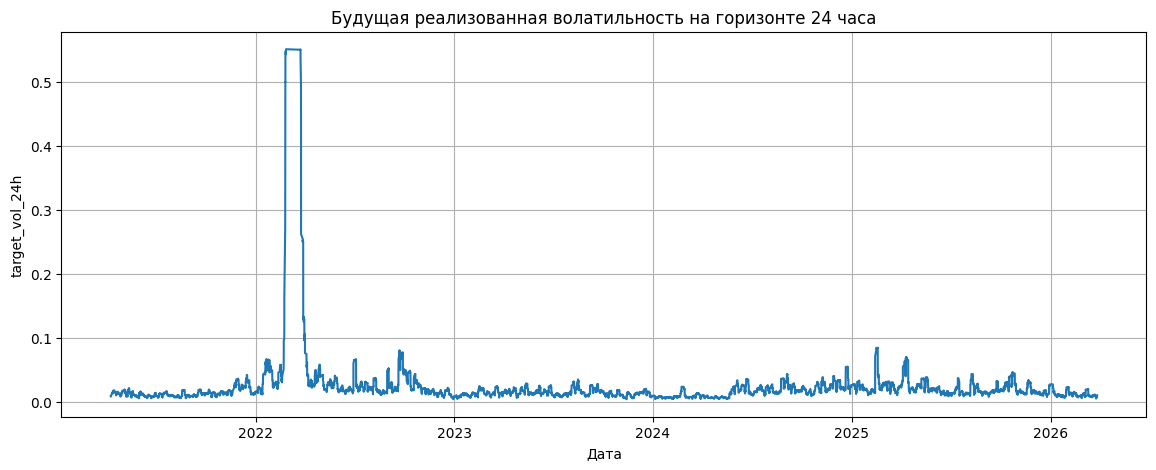

In [22]:
plt.figure(figsize=(14, 5))
plt.plot(model_df.index, model_df["target_vol_24h"])
plt.title("Будущая реализованная волатильность на горизонте 24 часа")
plt.xlabel("Дата")
plt.ylabel("target_vol_24h")
plt.grid(True)
plt.show()

# EDA

In [23]:
eda_df = model_df.copy()
print("Размер таблицы для EDA:", eda_df.shape)
eda_df.head()

Размер таблицы для EDA: (11530, 57)


,open,high,low,close,volume,return_1h,log_return_1h,abs_return_1h,log_return_3h,log_return_6h,log_return_12h,log_return_24h,hl_range,co_change,rolling_std_6,rolling_std_12,rolling_std_24,rolling_std_72,rolling_absret_mean_6,rolling_absret_mean_24,rolling_absret_mean_72,rv_6,rv_24,rv_72,ma_6,ma_24,ma_72,price_to_ma_6,price_to_ma_24,price_to_ma_72,rolling_mean_ret_6,rolling_mean_ret_24,rolling_mean_ret_72,log_return_1h_lag1,log_return_1h_lag2,log_return_1h_lag3,abs_return_1h_lag1,abs_return_1h_lag2,abs_return_1h_lag3,hl_range_lag1,hl_range_lag2,hl_range_lag3,co_change_lag1,co_change_lag2,co_change_lag3,rolling_std_24_lag1,rolling_std_24_lag2,rolling_std_24_lag3,rv_24_lag1,rv_24_lag2,rv_24_lag3,price_to_ma_24_lag1,price_to_ma_24_lag2,price_to_ma_24_lag3,hour,day_of_week,target_vol_24h
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2021-04-09 13:00:00,3483.47,3489.57,3482.50,3488.88,0,0.001559,0.001558,0.001558,-0.000556,-0.003076,-0.004102,-0.001409,0.002026,0.001553,0.001462,0.001367,0.001949,0.002671,0.001293,0.001532,0.001896,0.003503,0.009350,0.022529,3492.206667,3502.014167,3520.910417,-0.000953,-0.003750,-0.009097,-0.000513,-0.000059,-0.000108,-0.001386,-0.000728,-0.002466,0.001386,0.000728,0.002466,0.002090,0.003191,0.003326,-0.001393,-0.000742,-0.002486,0.001918,0.001939,0.001946,0.009220,0.009328,0.009343,-0.005359,-0.004104,-0.003527,13,4,0.009111
2021-04-09 14:00:00,3488.75,3489.50,3485.35,3486.99,0,-0.000542,-0.000542,0.000542,-0.000370,-0.004401,-0.005494,-0.004121,0.001190,-0.000504,0.001321,0.001314,0.001892,0.002669,0.001253,0.001465,0.001886,0.003457,0.009111,0.022503,3489.643333,3501.414167,3520.563333,-0.000760,-0.004120,-0.009536,-0.000733,-0.000172,-0.000099,0.001558,-0.001386,-0.000728,0.001558,0.001386,0.000728,0.002026,0.002090,0.003191,0.001553,-0.001393,-0.000742,0.001949,0.001918,0.001939,0.009350,0.009220,0.009328,-0.003750,-0.005359,-0.004104,14,4,0.008893
2021-04-09 15:00:00,3487.00,3490.07,3485.13,3486.03,0,-0.000275,-0.000275,0.000275,0.000740,-0.003839,-0.005972,-0.002398,0.001417,-0.000278,0.001332,0.001300,0.001852,0.002628,0.001159,0.001393,0.001838,0.003366,0.008893,0.022187,3487.408333,3501.065417,3520.018889,-0.000395,-0.004295,-0.009656,-0.000640,-0.000100,-0.000155,-0.000542,0.001558,-0.001386,0.000542,0.001558,0.001386,0.001190,0.002026,0.002090,-0.000504,0.001553,-0.001393,0.001892,0.001949,0.001918,0.009111,0.009350,0.009220,-0.004120,-0.003750,-0.005359,15,4,0.008435
2021-04-12 07:00:00,3476.51,3494.69,3472.37,3478.40,0,-0.002189,-0.002191,0.002191,-0.003008,-0.003564,-0.006999,-0.008160,0.006417,0.000544,0.001259,0.001379,0.001724,0.002635,0.001113,0.001335,0.001849,0.003170,0.008435,0.022251,3485.338333,3499.877917,3519.436667,-0.001991,-0.006137,-0.011660,-0.000594,-0.000340,-0.000166,-0.000275,-0.000542,0.001558,0.000275,0.000542,0.001558,0.001417,0.001190,0.002026,-0.000278,-0.000504,0.001553,0.001852,0.001892,0.001949,0.008893,0.009111,0.009350,-0.004295,-0.004120,-0.003750,7,0,0.014850
2021-04-12 08:00:00,3478.30,3527.60,3478.30,3521.28,0,0.012328,0.012252,0.012252,0.009786,0.009416,0.005268,0.004942,0.014001,0.012357,0.005382,0.003963,0.003089,0.003014,0.003034,0.001810,0.002015,0.012635,0.014850,0.025400,3490.838333,3500.601250,3519.465556,0.008720,0.005907,0.000516,0.001569,0.000206,0.000008,-0.002191,-0.000275,-0.000542,0.002191,0.000275,0.000542,0.006417,0.001417,0.001190,0.000544,-0.000278,-0.000504,0.001724,0.001852,0.001892,0.008435,0.008893,0.009111,-0.006137,-0.004295,-0.004120,8,0,0.014935


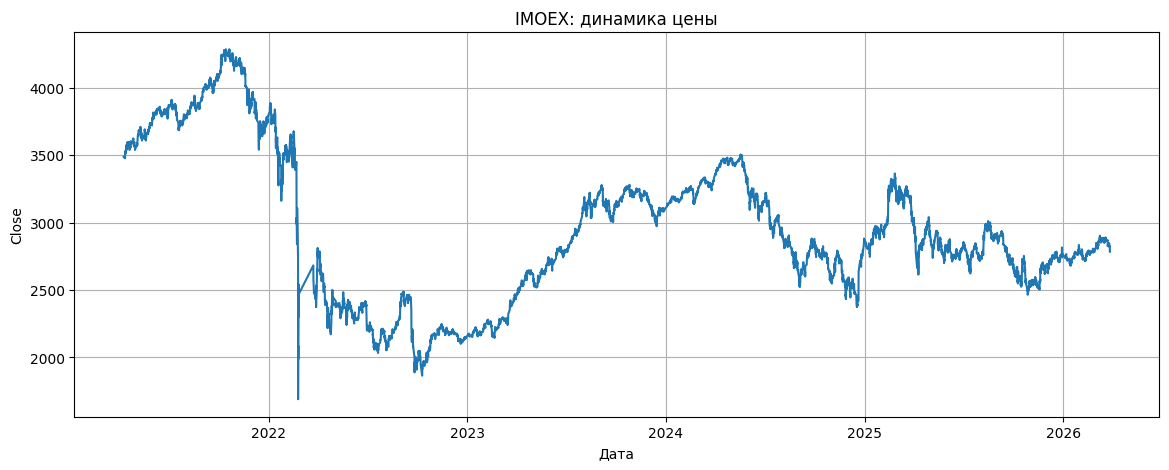

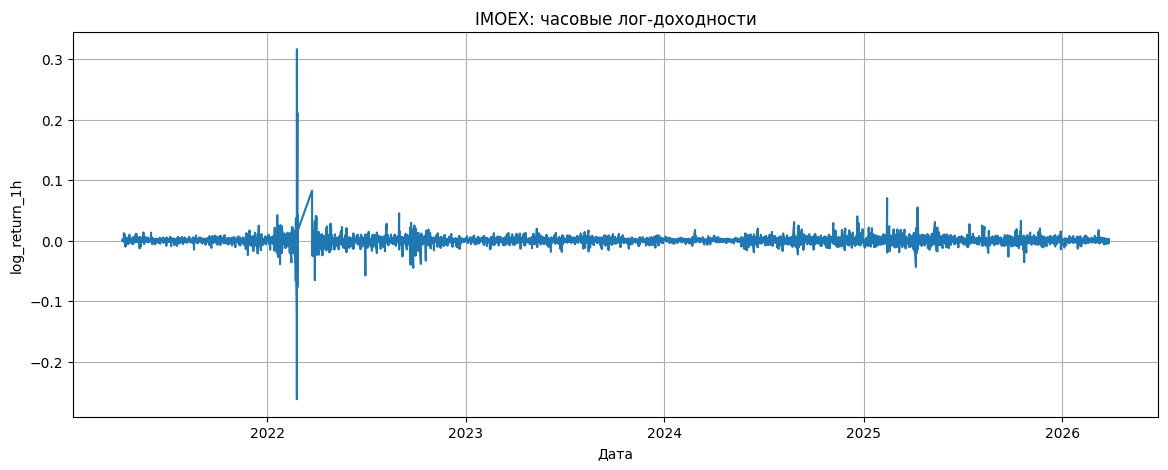

In [24]:
plt.figure(figsize=(14, 5))
plt.plot(eda_df.index, eda_df["close"])
plt.title("IMOEX: динамика цены")
plt.xlabel("Дата")
plt.ylabel("Close")
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(eda_df.index, eda_df["log_return_1h"])
plt.title("IMOEX: часовые лог-доходности")
plt.xlabel("Дата")
plt.ylabel("log_return_1h")
plt.grid(True)
plt.show()

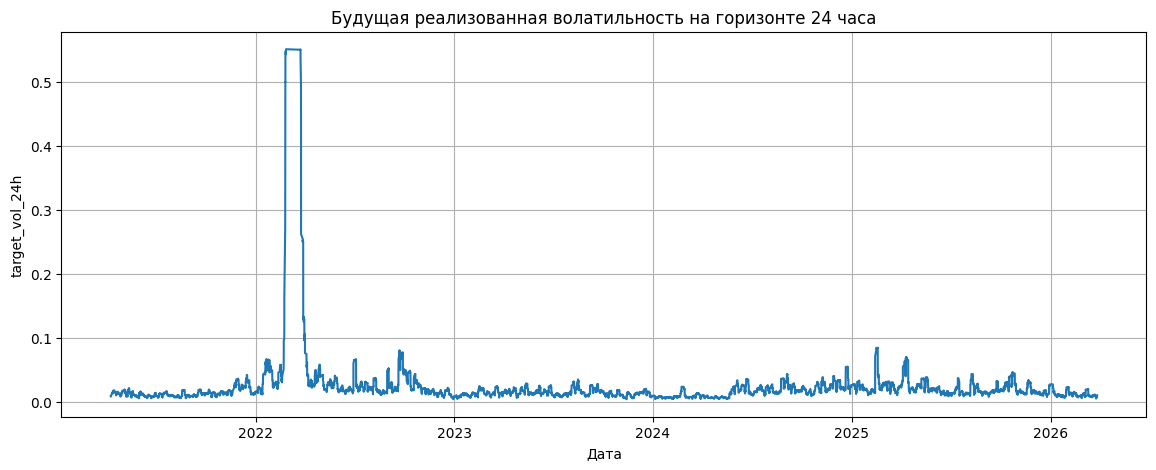

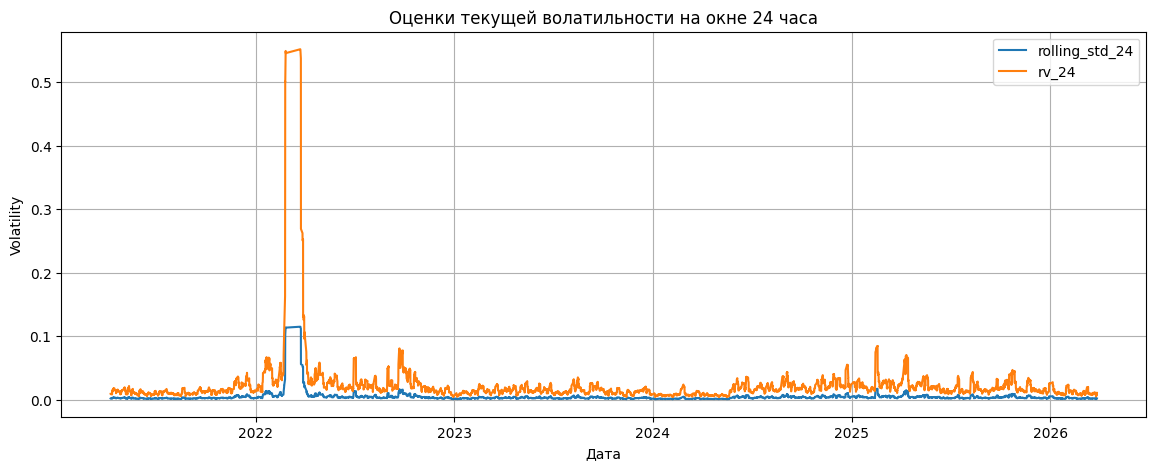

In [25]:
plt.figure(figsize=(14, 5))
plt.plot(eda_df.index, eda_df["target_vol_24h"])
plt.title("Будущая реализованная волатильность на горизонте 24 часа")
plt.xlabel("Дата")
plt.ylabel("target_vol_24h")
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(eda_df.index, eda_df["rolling_std_24"], label="rolling_std_24")
plt.plot(eda_df.index, eda_df["rv_24"], label="rv_24")
plt.title("Оценки текущей волатильности на окне 24 часа")
plt.xlabel("Дата")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True)
plt.show()

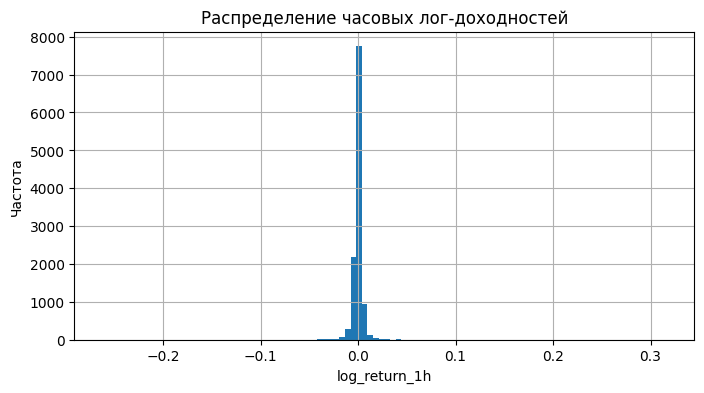

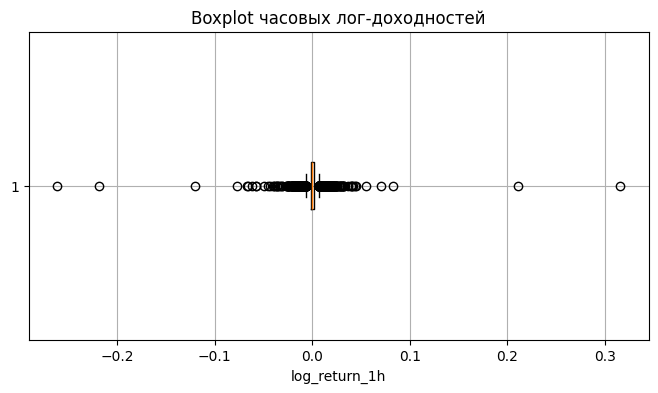

In [26]:
plt.figure(figsize=(8, 4))
plt.hist(eda_df["log_return_1h"], bins=100)
plt.title("Распределение часовых лог-доходностей")
plt.xlabel("log_return_1h")
plt.ylabel("Частота")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.boxplot(eda_df["log_return_1h"].dropna(), vert=False)
plt.title("Boxplot часовых лог-доходностей")
plt.xlabel("log_return_1h")
plt.grid(True)
plt.show()

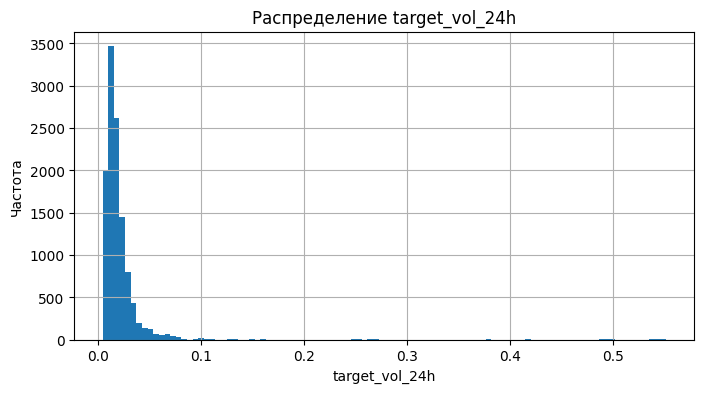

,log_return_1h,abs_return_1h,hl_range,co_change,rolling_std_24,rv_24,price_to_ma_24,rolling_mean_ret_24,target_vol_24h
log_return_1h,1.000000,0.002035,-0.092550,0.899153,0.022985,0.016475,0.327307,0.210705,-0.012439
abs_return_1h,0.002035,1.000000,0.848904,0.054812,0.464080,0.471027,-0.345269,-0.364211,0.505780
hl_range,-0.092550,0.848904,1.000000,-0.029254,0.538834,0.547447,-0.433296,-0.438833,0.575938
co_change,0.899153,0.054812,-0.029254,1.000000,0.026666,0.021286,0.242563,0.153892,-0.000663
rolling_std_24,0.022985,0.464080,0.538834,0.026666,1.000000,0.999610,-0.184963,-0.347974,0.991667
rv_24,0.016475,0.471027,0.547447,0.021286,0.999610,1.000000,-0.193592,-0.353199,0.992781
price_to_ma_24,0.327307,-0.345269,-0.433296,0.242563,-0.184963,-0.193592,1.000000,0.852400,-0.223630
rolling_mean_ret_24,0.210705,-0.364211,-0.438833,0.153892,-0.347974,-0.353199,0.852400,1.000000,-0.387587
target_vol_24h,-0.012439,0.505780,0.575938,-0.000663,0.991667,0.992781,-0.223630,-0.387587,1.000000


In [27]:
plt.figure(figsize=(8, 4))
plt.hist(eda_df["target_vol_24h"], bins=100)
plt.title("Распределение target_vol_24h")
plt.xlabel("target_vol_24h")
plt.ylabel("Частота")
plt.grid(True)
plt.show()

corr_cols = [
    "log_return_1h",
    "abs_return_1h",
    "hl_range",
    "co_change",
    "rolling_std_24",
    "rv_24",
    "price_to_ma_24",
    "rolling_mean_ret_24",
    "target_vol_24h"]

corr_matrix = eda_df[corr_cols].corr()
corr_matrix

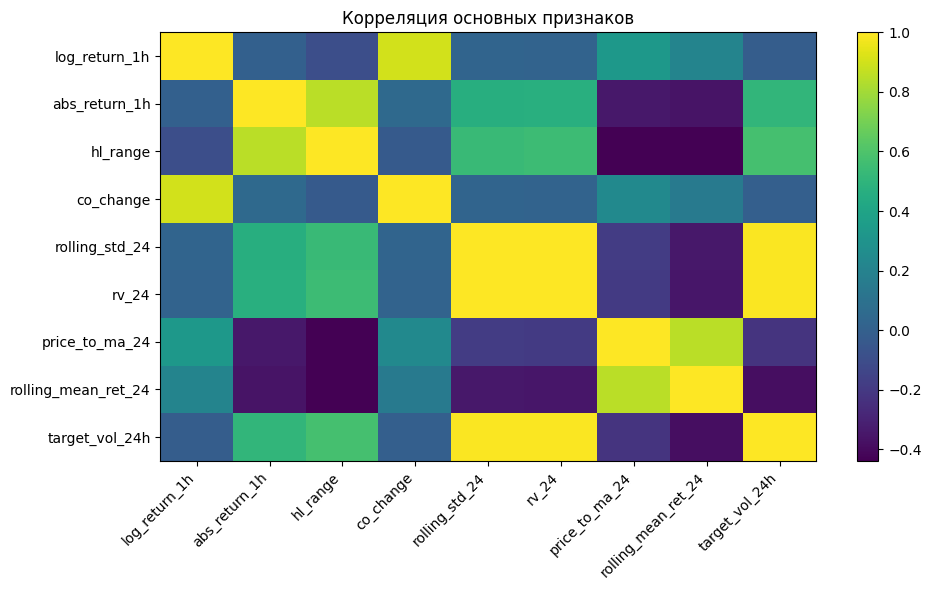

In [28]:
plt.figure(figsize=(10, 6))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Корреляция основных признаков")
plt.tight_layout()
plt.show()

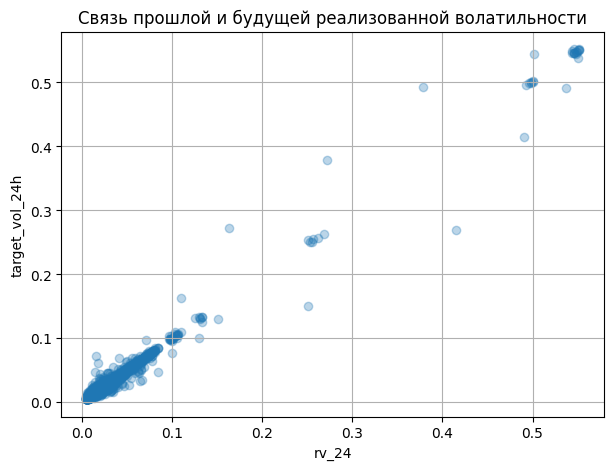

In [29]:
plt.figure(figsize=(7, 5))
plt.scatter(eda_df["rv_24"], eda_df["target_vol_24h"], alpha=0.3)
plt.title("Связь прошлой и будущей реализованной волатильности")
plt.xlabel("rv_24")
plt.ylabel("target_vol_24h")
plt.grid(True)
plt.show()

In [30]:
eda_stats = eda_df[[
    "log_return_1h",
    "abs_return_1h",
    "rolling_std_24",
    "rv_24",
    "target_vol_24h"]].describe()

eda_stats

,log_return_1h,abs_return_1h,rolling_std_24,rv_24,target_vol_24h
count,11530.000000,11530.000000,11530.000000,11530.000000,11530.000000
mean,-0.000019,0.002915,0.004129,0.020279,0.020280
std,0.006927,0.006284,0.005608,0.027210,0.027210
min,-0.262113,0.000000,0.000869,0.004349,0.004349
25%,-0.001610,0.000740,0.002344,0.011465,0.011465
50%,0.000092,0.001666,0.003208,0.015760,0.015760
75%,0.001713,0.003434,0.004578,0.022622,0.022622
max,0.316118,0.316118,0.115034,0.551883,0.551883


Разведочный анализ показал, что ряд IMOEX обладает типичными свойствами финансовых временных рядов: нестационарностью, тяжелыми хвостами распределения доходностей, наличием выбросов и выраженной кластеризацией волатильности. Будущая реализованная волатильность имеет правосторонне-асимметричное распределение и резко возрастает в стрессовые периоды, особенно в феврале–марте 2022 года. Наиболее сильная связь с target наблюдается у признаков, описывающих текущий уровень риска: rolling_std_24, rv_24, hl_range и abs_return_1h. Это подтверждает, что выбранный набор признаков подходит для построения моделей прогнозирования волатильности.

# Базовая GARCH модель

В качестве базовой модели использую `GARCH(1,1)`.  
На вход модели подаются часовые лог-доходности, на выходе получается оценка условной волатильности.

In [31]:
from arch import arch_model

garch_df = model_df.copy()
garch_df["log_return_pct"] = garch_df["log_return_1h"] * 100

garch_model = arch_model(
    garch_df["log_return_pct"],
    mean="Zero",
    vol="GARCH",
    p=1,
    q=1,
    dist="normal")

garch_result = garch_model.fit(disp="off")
print(garch_result.summary())


                       Zero Mean - GARCH Model Results                        
Dep. Variable:         log_return_pct   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -5550.77
Distribution:                  Normal   AIC:                           11107.5
Method:            Maximum Likelihood   BIC:                           11129.6
                                        No. Observations:                11530
Date:                Sun, Mar 29 2026   Df Residuals:                    11530
Time:                        13:09:28   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      1.1325e-03  3.874e-04      2.924  3.460e-03 [3.

In [32]:
garch_df["garch_volatility_pct"] = garch_result.conditional_volatility
garch_df["garch_volatility"] = garch_df["garch_volatility_pct"] / 100
garch_df[["log_return_1h", "garch_volatility"]].head()

,log_return_1h,garch_volatility
date,,
2021-04-09 13:00:00,0.001558,0.003584
2021-04-09 14:00:00,-0.000542,0.003518
2021-04-09 15:00:00,-0.000275,0.003437
2021-04-12 07:00:00,-0.002191,0.003357
2021-04-12 08:00:00,0.012252,0.003320


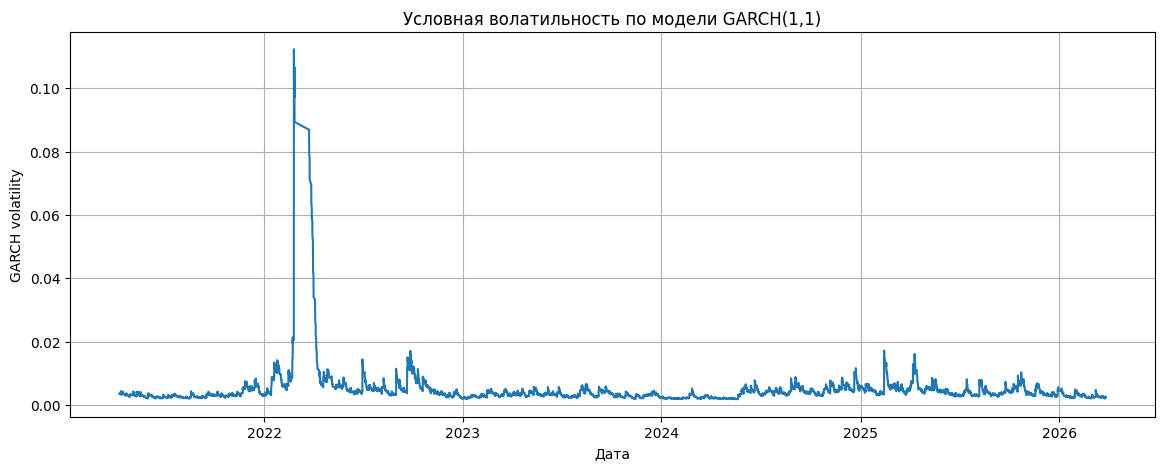

In [33]:
plt.figure(figsize=(14, 5))
plt.plot(garch_df.index, garch_df["garch_volatility"])
plt.title("Условная волатильность по модели GARCH(1,1)")
plt.xlabel("Дата")
plt.ylabel("GARCH volatility")
plt.grid(True)
plt.show()

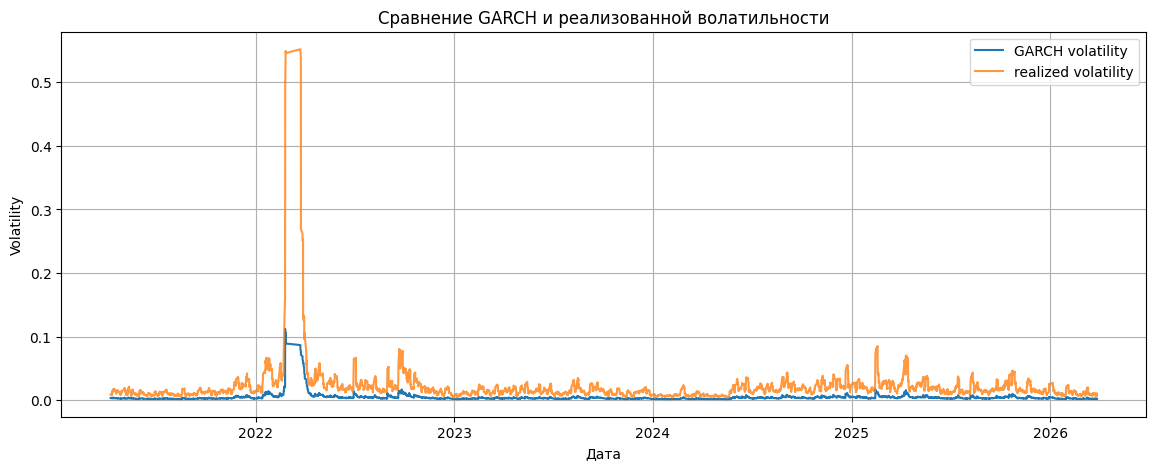

In [34]:
plt.figure(figsize=(14, 5))
plt.plot(garch_df.index, garch_df["garch_volatility"], label="GARCH volatility")
plt.plot(garch_df.index, garch_df["rv_24"], label="realized volatility", alpha=0.8)
plt.title("Сравнение GARCH и реализованной волатильности")
plt.xlabel("Дата")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True)
plt.show()

In [35]:
garch_df[["garch_volatility", "rv_24", "target_vol_24h"]].describe()

,garch_volatility,rv_24,target_vol_24h
count,11530.000000,11530.000000,11530.000000
mean,0.004589,0.020279,0.020280
std,0.005382,0.027210,0.027210
min,0.001787,0.004349,0.004349
25%,0.002849,0.011465,0.011465
50%,0.003631,0.015760,0.015760
75%,0.004941,0.022622,0.022622
max,0.112304,0.551883,0.551883


In [36]:
corr_garch_target = garch_df[["garch_volatility", "target_vol_24h"]].corr()
corr_garch_target

,garch_volatility,target_vol_24h
garch_volatility,1.000000,0.942744
target_vol_24h,0.942744,1.000000


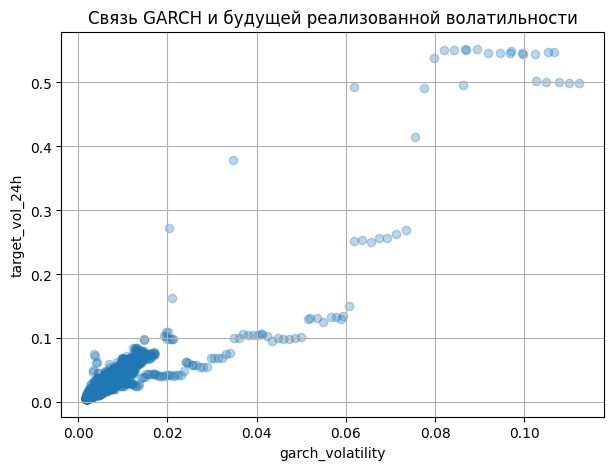

In [37]:
plt.figure(figsize=(7, 5))
plt.scatter(garch_df["garch_volatility"], garch_df["target_vol_24h"], alpha=0.3)
plt.title("Связь GARCH и будущей реализованной волатильности")
plt.xlabel("garch_volatility")
plt.ylabel("target_vol_24h")
plt.grid(True)
plt.show()

По результатам оценки модели GARCH(1,1) видно, что она хорошо улавливает кластеризацию волатильности в ряде IMOEX. Полученные параметры экономически осмысленны: коэффициент `beta` близок к 1, что говорит о высокой инерционности волатильности, а коэффициент `alpha` показывает реакцию модели на новые шоки.

Условная волатильность GARCH положительно связана с будущей реализованной волатильностью, что подтверждается графически. При этом GARCH дает более сглаженную оценку риска и в меньшей степени отражает экстремальные пики по сравнению с реализованной волатильностью.

# Подготовка последовательностей для DL

Так как LSTM работает с последовательностями, нужно превратить данные в набор окон фиксированной длины: модель будет смотреть на несколько последних наблюдений и по ним предсказывать будущую волатильность.

Также важно не допустить утечки данных. Поэтому масштабирование признаков делается только на train-части, а не на всем датасете сразу, чтобы не допустить утечки данных

In [38]:
from sklearn.preprocessing import StandardScaler
dl_df = model_df.copy()

print(dl_df.shape)
dl_df.head()

(11530, 57)


,open,high,low,close,volume,return_1h,log_return_1h,abs_return_1h,log_return_3h,log_return_6h,log_return_12h,log_return_24h,hl_range,co_change,rolling_std_6,rolling_std_12,rolling_std_24,rolling_std_72,rolling_absret_mean_6,rolling_absret_mean_24,rolling_absret_mean_72,rv_6,rv_24,rv_72,ma_6,ma_24,ma_72,price_to_ma_6,price_to_ma_24,price_to_ma_72,rolling_mean_ret_6,rolling_mean_ret_24,rolling_mean_ret_72,log_return_1h_lag1,log_return_1h_lag2,log_return_1h_lag3,abs_return_1h_lag1,abs_return_1h_lag2,abs_return_1h_lag3,hl_range_lag1,hl_range_lag2,hl_range_lag3,co_change_lag1,co_change_lag2,co_change_lag3,rolling_std_24_lag1,rolling_std_24_lag2,rolling_std_24_lag3,rv_24_lag1,rv_24_lag2,rv_24_lag3,price_to_ma_24_lag1,price_to_ma_24_lag2,price_to_ma_24_lag3,hour,day_of_week,target_vol_24h
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2021-04-09 13:00:00,3483.47,3489.57,3482.50,3488.88,0,0.001559,0.001558,0.001558,-0.000556,-0.003076,-0.004102,-0.001409,0.002026,0.001553,0.001462,0.001367,0.001949,0.002671,0.001293,0.001532,0.001896,0.003503,0.009350,0.022529,3492.206667,3502.014167,3520.910417,-0.000953,-0.003750,-0.009097,-0.000513,-0.000059,-0.000108,-0.001386,-0.000728,-0.002466,0.001386,0.000728,0.002466,0.002090,0.003191,0.003326,-0.001393,-0.000742,-0.002486,0.001918,0.001939,0.001946,0.009220,0.009328,0.009343,-0.005359,-0.004104,-0.003527,13,4,0.009111
2021-04-09 14:00:00,3488.75,3489.50,3485.35,3486.99,0,-0.000542,-0.000542,0.000542,-0.000370,-0.004401,-0.005494,-0.004121,0.001190,-0.000504,0.001321,0.001314,0.001892,0.002669,0.001253,0.001465,0.001886,0.003457,0.009111,0.022503,3489.643333,3501.414167,3520.563333,-0.000760,-0.004120,-0.009536,-0.000733,-0.000172,-0.000099,0.001558,-0.001386,-0.000728,0.001558,0.001386,0.000728,0.002026,0.002090,0.003191,0.001553,-0.001393,-0.000742,0.001949,0.001918,0.001939,0.009350,0.009220,0.009328,-0.003750,-0.005359,-0.004104,14,4,0.008893
2021-04-09 15:00:00,3487.00,3490.07,3485.13,3486.03,0,-0.000275,-0.000275,0.000275,0.000740,-0.003839,-0.005972,-0.002398,0.001417,-0.000278,0.001332,0.001300,0.001852,0.002628,0.001159,0.001393,0.001838,0.003366,0.008893,0.022187,3487.408333,3501.065417,3520.018889,-0.000395,-0.004295,-0.009656,-0.000640,-0.000100,-0.000155,-0.000542,0.001558,-0.001386,0.000542,0.001558,0.001386,0.001190,0.002026,0.002090,-0.000504,0.001553,-0.001393,0.001892,0.001949,0.001918,0.009111,0.009350,0.009220,-0.004120,-0.003750,-0.005359,15,4,0.008435
2021-04-12 07:00:00,3476.51,3494.69,3472.37,3478.40,0,-0.002189,-0.002191,0.002191,-0.003008,-0.003564,-0.006999,-0.008160,0.006417,0.000544,0.001259,0.001379,0.001724,0.002635,0.001113,0.001335,0.001849,0.003170,0.008435,0.022251,3485.338333,3499.877917,3519.436667,-0.001991,-0.006137,-0.011660,-0.000594,-0.000340,-0.000166,-0.000275,-0.000542,0.001558,0.000275,0.000542,0.001558,0.001417,0.001190,0.002026,-0.000278,-0.000504,0.001553,0.001852,0.001892,0.001949,0.008893,0.009111,0.009350,-0.004295,-0.004120,-0.003750,7,0,0.014850
2021-04-12 08:00:00,3478.30,3527.60,3478.30,3521.28,0,0.012328,0.012252,0.012252,0.009786,0.009416,0.005268,0.004942,0.014001,0.012357,0.005382,0.003963,0.003089,0.003014,0.003034,0.001810,0.002015,0.012635,0.014850,0.025400,3490.838333,3500.601250,3519.465556,0.008720,0.005907,0.000516,0.001569,0.000206,0.000008,-0.002191,-0.000275,-0.000542,0.002191,0.000275,0.000542,0.006417,0.001417,0.001190,0.000544,-0.000278,-0.000504,0.001724,0.001852,0.001892,0.008435,0.008893,0.009111,-0.006137,-0.004295,-0.004120,8,0,0.014935


In [39]:
lookback = 24

X_data = dl_df[feature_cols].copy()
y_data = dl_df["target_vol_24h"].copy()

print("Размер X:", X_data.shape)
print("Размер y:", y_data.shape)

Размер X: (11530, 51)
Размер y: (11530,)


In [40]:
n = len(dl_df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train_raw = X_data.iloc[:train_end].copy()
X_val_raw = X_data.iloc[train_end:val_end].copy()
X_test_raw = X_data.iloc[val_end:].copy()

y_train_raw = y_data.iloc[:train_end].copy()
y_val_raw = y_data.iloc[train_end:val_end].copy()
y_test_raw = y_data.iloc[val_end:].copy()

print("Train:", X_train_raw.shape, y_train_raw.shape)
print("Val:", X_val_raw.shape, y_val_raw.shape)
print("Test:", X_test_raw.shape, y_test_raw.shape)

Train: (8070, 51) (8070,)
Val: (1730, 51) (1730,)
Test: (1730, 51) (1730,)


In [41]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)
X_test_scaled = scaler.transform(X_test_raw)

print(X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)

(8070, 51) (1730, 51) (1730, 51)


In [42]:
def make_sequences(X, y, lookback):
    X_seq = []
    y_seq = []

    for i in range(lookback, len(X)):
        X_seq.append(X[i - lookback:i])
        y_seq.append(y.iloc[i])

    return np.array(X_seq), np.array(y_seq)

In [43]:
X_train_seq, y_train_seq = make_sequences(
    X_train_scaled,
    y_train_raw.reset_index(drop=True),
    lookback)

X_val_seq, y_val_seq = make_sequences(
    X_val_scaled,
    y_val_raw.reset_index(drop=True),
    lookback)

X_test_seq, y_test_seq = make_sequences(
    X_test_scaled,
    y_test_raw.reset_index(drop=True),
    lookback)

print("X_train_seq:", X_train_seq.shape)
print("y_train_seq:", y_train_seq.shape)

print("X_val_seq:", X_val_seq.shape)
print("y_val_seq:", y_val_seq.shape)

print("X_test_seq:", X_test_seq.shape)
print("y_test_seq:", y_test_seq.shape)

X_train_seq: (8046, 24, 51)
y_train_seq: (8046,)
X_val_seq: (1706, 24, 51)
y_val_seq: (1706,)
X_test_seq: (1706, 24, 51)
y_test_seq: (1706,)


In [44]:
print("Форма одного объекта:", X_train_seq[0].shape)
print("Target первого объекта:", y_train_seq[0])

n_features = X_train_seq.shape[2]
print("Количество признаков:", n_features)

Форма одного объекта: (24, 51)
Target первого объекта: 0.017586343887302007
Количество признаков: 51


In [45]:
dl_data = {
    "X_train_seq": X_train_seq,
    "y_train_seq": y_train_seq,
    "X_val_seq": X_val_seq,
    "y_val_seq": y_val_seq,
    "X_test_seq": X_test_seq,
    "y_test_seq": y_test_seq,
    "scaler": scaler,
    "lookback": lookback,
    "n_features": n_features}

print("Train target mean:", y_train_seq.mean())
print("Val target mean:", y_val_seq.mean())
print("Test target mean:", y_test_seq.mean())

Train target mean: 0.020254746097262858
Val target mean: 0.02419740770658111
Test target mean: 0.016513019717505975


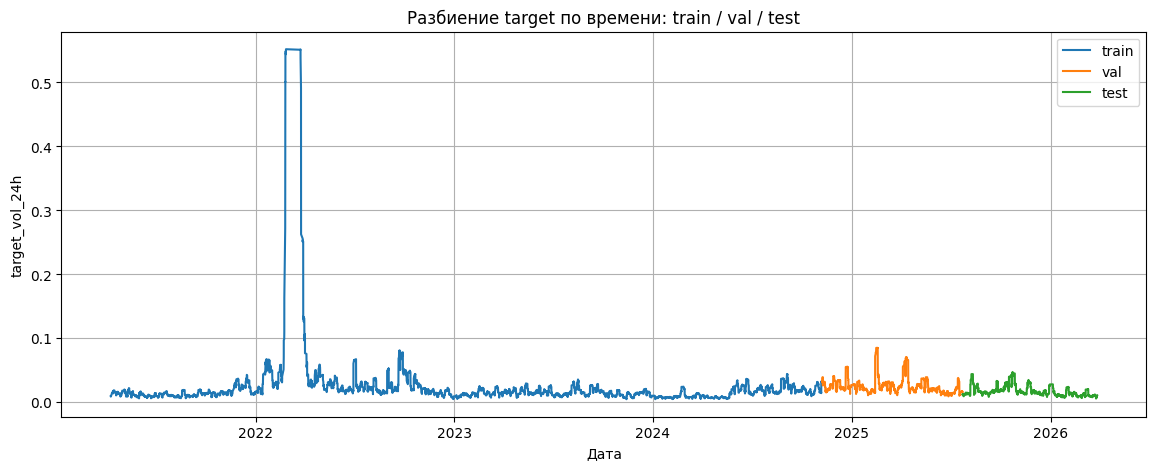

In [46]:
plt.figure(figsize=(14, 5))
plt.plot(y_train_raw.index, y_train_raw.values, label="train")
plt.plot(y_val_raw.index, y_val_raw.values, label="val")
plt.plot(y_test_raw.index, y_test_raw.values, label="test")
plt.title("Разбиение target по времени: train / val / test")
plt.xlabel("Дата")
plt.ylabel("target_vol_24h")
plt.legend()
plt.grid(True)
plt.show()

# DL-модель

In [47]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

print("X_train_seq:", X_train_seq.shape)
print("X_val_seq:", X_val_seq.shape)
print("X_test_seq:", X_test_seq.shape)

lstm_model = Sequential([
    LSTM(32, input_shape=(lookback, n_features)),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)])

lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"])

lstm_model.summary()

X_train_seq: (8046, 24, 51)
X_val_seq: (1706, 24, 51)
X_test_seq: (1706, 24, 51)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │        10,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,297 (44.13 KB)

 Trainable params: 11,297 (44.13 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True)

history = lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1)

test_loss, test_mae = lstm_model.evaluate(X_test_seq, y_test_seq, verbose=0)

print("Test loss (MSE):", test_loss)
print("Test MAE:", test_mae)

Epoch 1/30
252/252 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0070 - mae: 0.0518 - val_loss: 0.0010 - val_mae: 0.0253
Epoch 2/30
252/252 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0011 - mae: 0.0205 - val_loss: 3.6459e-04 - val_mae: 0.0143
Epoch 3/30
252/252 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5.0715e-04 - mae: 0.0128 - val_loss: 1.9205e-04 - val_mae: 0.0090
Epoch 4/30
252/252 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 2.8196e-04 - mae: 0.0092 - val_loss: 1.1850e-04 - val_mae: 0.0071
Epoch 5/30
252/252 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 2.6023e-04 - mae: 0.0077 - val_loss: 8.3798e-05 - val_mae: 0.0058
Epoch 6/30
252/252 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 2.0564e-04 - mae: 0.0065 - val_loss: 6.9301e-05 - val_mae: 0.0052
Epoch 7/30
252/252 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 2.8496e-04 - mae: 0.0063 - val_loss: 7.3258e-05 - val_mae: 0.0056
Epoch 8/30
252/252 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 1.9454e-04 - mae: 0.0059 - val_loss: 6.3117e-05 - val_mae: 0.0

In [49]:
y_pred_test = lstm_model.predict(X_test_seq).flatten()

print("Форма предсказаний:", y_pred_test.shape)
print("Первые 10 прогнозов:", y_pred_test[:10])

54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Форма предсказаний: (1706,)
Первые 10 прогнозов: [0.01113231 0.01233568 0.01283623 0.01159327 0.01064559 0.00973677
 0.00967393 0.00946057 0.01062109 0.0122796 ]


In [50]:
history_df = pd.DataFrame(history.history)
history_df.head()

,loss,mae,val_loss,val_mae
0,0.006955,0.051831,0.001049,0.025340
1,0.001077,0.020493,0.000365,0.014269
2,0.000507,0.012841,0.000192,0.008995
3,0.000282,0.009232,0.000119,0.007140
4,0.000260,0.007716,0.000084,0.005813


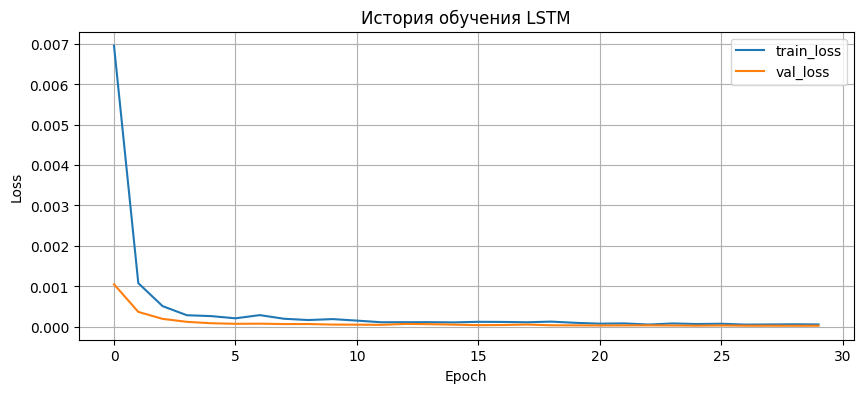

In [51]:
plt.figure(figsize=(10, 4))
plt.plot(history_df["loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.title("История обучения LSTM")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

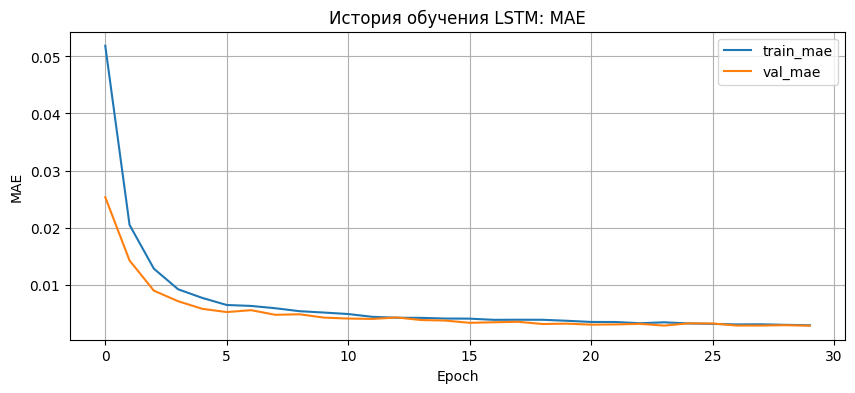

In [52]:
plt.figure(figsize=(10, 4))
plt.plot(history_df["mae"], label="train_mae")
plt.plot(history_df["val_mae"], label="val_mae")
plt.title("История обучения LSTM: MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.show()

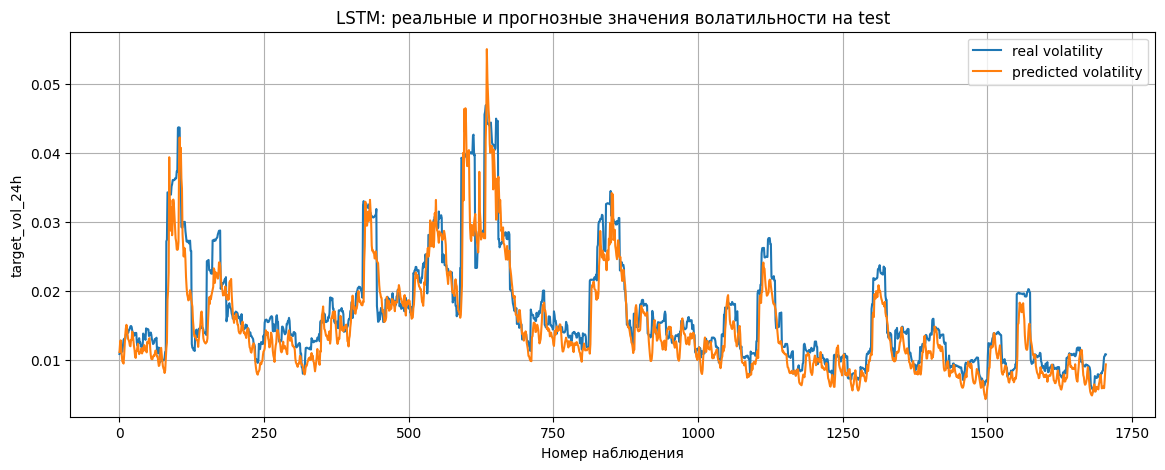

In [53]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_seq, label="real volatility")
plt.plot(y_pred_test, label="predicted volatility")
plt.title("LSTM: реальные и прогнозные значения волатильности на test")
plt.xlabel("Номер наблюдения")
plt.ylabel("target_vol_24h")
plt.legend()
plt.grid(True)
plt.show()

In [54]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse_lstm = np.sqrt(mean_squared_error(y_test_seq, y_pred_test))
mae_lstm = mean_absolute_error(y_test_seq, y_pred_test)

print("LSTM RMSE:", rmse_lstm)
print("LSTM MAE:", mae_lstm)

LSTM RMSE: 0.0033165356245274235
LSTM MAE: 0.002343179733030059


In [55]:
dl_results = pd.DataFrame({
    "y_true": y_test_seq,
    "y_pred_lstm": y_pred_test})

dl_results.head()

,y_true,y_pred_lstm
0,0.010852,0.011132
1,0.011294,0.012336
2,0.011010,0.012836
3,0.011776,0.011593
4,0.011305,0.010646


### Выводы по DL-модели

По результатам обучения видно, что модель обучается стабильно: функции потерь на train и validation выборках убывают без явных признаков переобучения.

На тестовой выборке модель показала хорошие результаты:
- RMSE = 0.00293
- MAE = 0.00187

График реальных и прогнозных значений показывает, что модель хорошо воспроизводит общую динамику волатильности и улавливает основные режимы рынка.

# Walk-forward validation

Рразбиваю данные по времени: сначала беру участок для обучения, потом следующий участок для теста, затем окно сдвигается вперед, и процедура повторяется.

В каждом окне:
- обучаю модель только на прошлых данных,
- делаю прогноз только на следующем будущем отрезке,
- сохраняю реальные и прогнозные значения.

In [56]:
# walk-forward для GARCH
from sklearn.metrics import mean_squared_error, mean_absolute_error

wf_df = model_df.copy()
print(wf_df.shape)
wf_df.head()

(11530, 57)


,open,high,low,close,volume,return_1h,log_return_1h,abs_return_1h,log_return_3h,log_return_6h,log_return_12h,log_return_24h,hl_range,co_change,rolling_std_6,rolling_std_12,rolling_std_24,rolling_std_72,rolling_absret_mean_6,rolling_absret_mean_24,rolling_absret_mean_72,rv_6,rv_24,rv_72,ma_6,ma_24,ma_72,price_to_ma_6,price_to_ma_24,price_to_ma_72,rolling_mean_ret_6,rolling_mean_ret_24,rolling_mean_ret_72,log_return_1h_lag1,log_return_1h_lag2,log_return_1h_lag3,abs_return_1h_lag1,abs_return_1h_lag2,abs_return_1h_lag3,hl_range_lag1,hl_range_lag2,hl_range_lag3,co_change_lag1,co_change_lag2,co_change_lag3,rolling_std_24_lag1,rolling_std_24_lag2,rolling_std_24_lag3,rv_24_lag1,rv_24_lag2,rv_24_lag3,price_to_ma_24_lag1,price_to_ma_24_lag2,price_to_ma_24_lag3,hour,day_of_week,target_vol_24h
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2021-04-09 13:00:00,3483.47,3489.57,3482.50,3488.88,0,0.001559,0.001558,0.001558,-0.000556,-0.003076,-0.004102,-0.001409,0.002026,0.001553,0.001462,0.001367,0.001949,0.002671,0.001293,0.001532,0.001896,0.003503,0.009350,0.022529,3492.206667,3502.014167,3520.910417,-0.000953,-0.003750,-0.009097,-0.000513,-0.000059,-0.000108,-0.001386,-0.000728,-0.002466,0.001386,0.000728,0.002466,0.002090,0.003191,0.003326,-0.001393,-0.000742,-0.002486,0.001918,0.001939,0.001946,0.009220,0.009328,0.009343,-0.005359,-0.004104,-0.003527,13,4,0.009111
2021-04-09 14:00:00,3488.75,3489.50,3485.35,3486.99,0,-0.000542,-0.000542,0.000542,-0.000370,-0.004401,-0.005494,-0.004121,0.001190,-0.000504,0.001321,0.001314,0.001892,0.002669,0.001253,0.001465,0.001886,0.003457,0.009111,0.022503,3489.643333,3501.414167,3520.563333,-0.000760,-0.004120,-0.009536,-0.000733,-0.000172,-0.000099,0.001558,-0.001386,-0.000728,0.001558,0.001386,0.000728,0.002026,0.002090,0.003191,0.001553,-0.001393,-0.000742,0.001949,0.001918,0.001939,0.009350,0.009220,0.009328,-0.003750,-0.005359,-0.004104,14,4,0.008893
2021-04-09 15:00:00,3487.00,3490.07,3485.13,3486.03,0,-0.000275,-0.000275,0.000275,0.000740,-0.003839,-0.005972,-0.002398,0.001417,-0.000278,0.001332,0.001300,0.001852,0.002628,0.001159,0.001393,0.001838,0.003366,0.008893,0.022187,3487.408333,3501.065417,3520.018889,-0.000395,-0.004295,-0.009656,-0.000640,-0.000100,-0.000155,-0.000542,0.001558,-0.001386,0.000542,0.001558,0.001386,0.001190,0.002026,0.002090,-0.000504,0.001553,-0.001393,0.001892,0.001949,0.001918,0.009111,0.009350,0.009220,-0.004120,-0.003750,-0.005359,15,4,0.008435
2021-04-12 07:00:00,3476.51,3494.69,3472.37,3478.40,0,-0.002189,-0.002191,0.002191,-0.003008,-0.003564,-0.006999,-0.008160,0.006417,0.000544,0.001259,0.001379,0.001724,0.002635,0.001113,0.001335,0.001849,0.003170,0.008435,0.022251,3485.338333,3499.877917,3519.436667,-0.001991,-0.006137,-0.011660,-0.000594,-0.000340,-0.000166,-0.000275,-0.000542,0.001558,0.000275,0.000542,0.001558,0.001417,0.001190,0.002026,-0.000278,-0.000504,0.001553,0.001852,0.001892,0.001949,0.008893,0.009111,0.009350,-0.004295,-0.004120,-0.003750,7,0,0.014850
2021-04-12 08:00:00,3478.30,3527.60,3478.30,3521.28,0,0.012328,0.012252,0.012252,0.009786,0.009416,0.005268,0.004942,0.014001,0.012357,0.005382,0.003963,0.003089,0.003014,0.003034,0.001810,0.002015,0.012635,0.014850,0.025400,3490.838333,3500.601250,3519.465556,0.008720,0.005907,0.000516,0.001569,0.000206,0.000008,-0.002191,-0.000275,-0.000542,0.002191,0.000275,0.000542,0.006417,0.001417,0.001190,0.000544,-0.000278,-0.000504,0.001724,0.001852,0.001892,0.008435,0.008893,0.009111,-0.006137,-0.004295,-0.004120,8,0,0.014935


In [57]:
wf_df["log_return_pct"] = wf_df["log_return_1h"] * 100

bars_per_day = 10
trading_days_per_year = 252

train_size = bars_per_day * trading_days_per_year * 2
test_size = bars_per_day * 63
step_size = test_size

print("train_size:", train_size)
print("test_size:", test_size)
print("step_size:", step_size)
print("Длина всего ряда:", len(wf_df))

train_size: 5040
test_size: 630
step_size: 630
Длина всего ряда: 11530


In [58]:
def walk_forward_garch(data, train_size, test_size, step_size):
    results = []

    start = 0
    n = len(data)

    while start + train_size + test_size <= n:
        train_slice = data.iloc[start:start + train_size].copy()
        test_slice = data.iloc[start + train_size:start + train_size + test_size].copy()

        model = arch_model(
            train_slice["log_return_pct"],
            mean="Zero",
            vol="GARCH",
            p=1,
            q=1,
            dist="normal")

        fitted = model.fit(disp="off")
        forecast = fitted.forecast(horizon=1, reindex=False)
        sigma1 = np.sqrt(forecast.variance.values[-1, 0]) / 100
        sigma24 = sigma1 * np.sqrt(24)
        test_pred = np.repeat(sigma24, len(test_slice))

        fold_result = pd.DataFrame({
            "date": test_slice.index,
            "y_true": test_slice["target_vol_24h"].values,
            "y_pred_garch": test_pred})

        results.append(fold_result)
        start += step_size

    if len(results) == 0:
        return pd.DataFrame()

    results_df = pd.concat(results, ignore_index=True)
    return results_df

In [59]:
garch_wf_results = walk_forward_garch(
    data=wf_df,
    train_size=train_size,
    test_size=test_size,
    step_size=step_size)

print(garch_wf_results.shape)
garch_wf_results.head()

(6300, 3)


,date,y_true,y_pred_garch
0,2023-07-17 09:00:00,0.007992,0.014613
1,2023-07-17 10:00:00,0.008240,0.014613
2,2023-07-17 11:00:00,0.008273,0.014613
3,2023-07-17 12:00:00,0.008223,0.014613
4,2023-07-17 13:00:00,0.008176,0.014613


In [60]:
garch_wf_rmse = np.sqrt(mean_squared_error(
    garch_wf_results["y_true"],
    garch_wf_results["y_pred_garch"]))

garch_wf_mae = mean_absolute_error(
    garch_wf_results["y_true"],
    garch_wf_results["y_pred_garch"])

print("Walk-forward GARCH RMSE:", garch_wf_rmse)
print("Walk-forward GARCH MAE:", garch_wf_mae)

Walk-forward GARCH RMSE: 0.009398441665712368
Walk-forward GARCH MAE: 0.0068016743520002


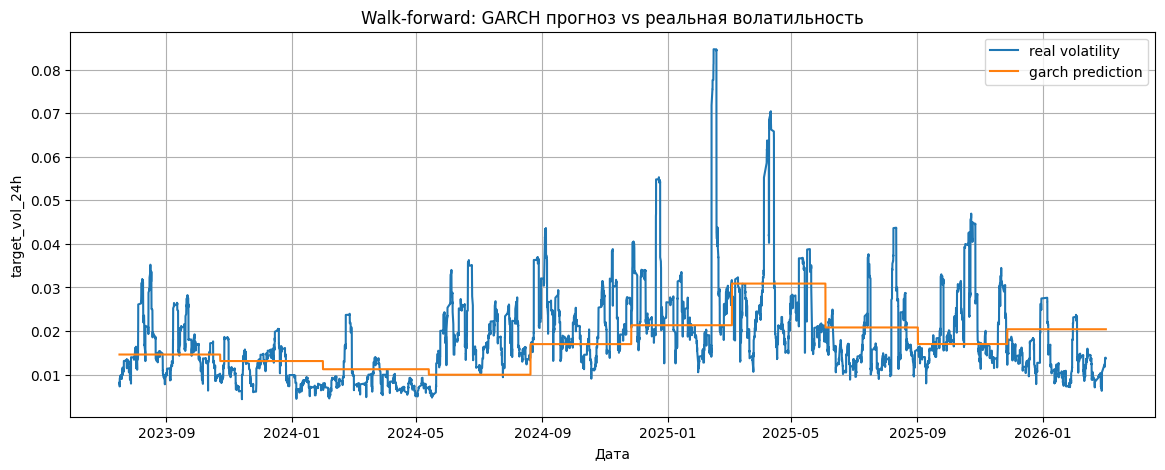

In [61]:
plt.figure(figsize=(14, 5))
plt.plot(garch_wf_results["date"], garch_wf_results["y_true"], label="real volatility")
plt.plot(garch_wf_results["date"], garch_wf_results["y_pred_garch"], label="garch prediction")
plt.title("Walk-forward: GARCH прогноз vs реальная волатильность")
plt.xlabel("Дата")
plt.ylabel("target_vol_24h")
plt.legend()
plt.grid(True)
plt.show()

In [62]:
import time
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

def build_lstm_model(lookback, n_features):
    model = Sequential([
        LSTM(32, input_shape=(lookback, n_features)),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dense(1)])
    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"])
    return model

def walk_forward_lstm_full(data, feature_cols, target_col, lookback, train_size, test_size, step_size):
    results = []

    start = 0
    n = len(data)
    fold_num = 0

    print("Общая длина ряда:", n)
    print("train_size:", train_size)
    print("test_size:", test_size)
    print("step_size:", step_size)

    if train_size + test_size > n:
        print("Слишком большие окна для текущего датасета")
        return pd.DataFrame()

    while start + train_size + test_size <= n:
        fold_start_time = time.time()
        fold_num += 1

        train_slice = data.iloc[start:start + train_size].copy()
        test_slice = data.iloc[start + train_size:start + train_size + test_size].copy()
        val_size = int(len(train_slice) * 0.15)
        train_part = train_slice.iloc[:-val_size].copy()
        val_part = train_slice.iloc[-val_size:].copy()

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(train_part[feature_cols])
        X_val_scaled = scaler.transform(val_part[feature_cols])
        X_test_scaled = scaler.transform(test_slice[feature_cols])

        y_train = train_part[target_col].reset_index(drop=True)
        y_val = val_part[target_col].reset_index(drop=True)
        y_test = test_slice[target_col].reset_index(drop=True)

        X_train_seq, y_train_seq = make_sequences(X_train_scaled, y_train, lookback)
        X_val_seq, y_val_seq = make_sequences(X_val_scaled, y_val, lookback)
        X_test_seq, y_test_seq = make_sequences(X_test_scaled, y_test, lookback)

        if len(X_train_seq) == 0 or len(X_val_seq) == 0 or len(X_test_seq) == 0:
            print(f"Fold {fold_num}: пропущен, слишком мало данных для последовательностей")
            start += step_size
            continue

        model = build_lstm_model(lookback, len(feature_cols))

        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True)

        history = model.fit(
            X_train_seq, y_train_seq,
            validation_data=(X_val_seq, y_val_seq),
            epochs=20,
            batch_size=32,
            callbacks=[early_stop],
            verbose=0)

        y_pred = model.predict(X_test_seq, verbose=0).flatten()
        fold_dates = test_slice.index[lookback:]
        fold_result = pd.DataFrame({
            "date": fold_dates,
            "y_true": y_test_seq,
            "y_pred_lstm": y_pred,
            "fold": fold_num})

        results.append(fold_result)
        fold_time = time.time() - fold_start_time
        best_val_loss = min(history.history["val_loss"])

        print(
            f"Fold {fold_num}: "
            f"train {train_slice.index.min()} - {train_slice.index.max()}, "
            f"test {test_slice.index.min()} - {test_slice.index.max()}, "
            f"best_val_loss={best_val_loss:.6f}, "
            f"time={fold_time:.1f} sec")

        start += step_size

    if len(results) == 0:
        return pd.DataFrame()

    results_df = pd.concat(results, ignore_index=True)
    return results_df

lstm_wf_results_full = walk_forward_lstm_full(
    data=wf_df,
    feature_cols=feature_cols,
    target_col="target_vol_24h",
    lookback=lookback,
    train_size=train_size,
    test_size=test_size,
    step_size=step_size)

print(lstm_wf_results_full.shape)
lstm_wf_results_full.head()

Общая длина ряда: 11530
train_size: 5040
test_size: 630
step_size: 630


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Fold 1: train 2021-04-09 13:00:00 - 2023-07-17 08:00:00, test 2023-07-17 09:00:00 - 2023-10-23 08:00:00, best_val_loss=0.000009, time=36.8 sec


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Fold 2: train 2021-07-19 13:00:00 - 2023-10-23 08:00:00, test 2023-10-23 09:00:00 - 2024-01-31 08:00:00, best_val_loss=0.000008, time=36.8 sec


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Fold 9: train 2023-07-17 09:00:00 - 2025-09-01 09:00:00, test 2025-09-01 10:00:00 - 2025-11-27 09:00:00, best_val_loss=0.000014, time=44.4 sec


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Fold 10: train 2023-10-23 09:00:00 - 2025-11-27 09:00:00, test 2025-11-27 10:00:00 - 2026-03-03 09:00:00, best_val_loss=0.000019, time=36.7 sec
(6060, 4)


,date,y_true,y_pred_lstm,fold
0,2023-07-19 15:00:00,0.009793,0.011759,1
1,2023-07-20 07:00:00,0.011346,0.011251,1
2,2023-07-20 08:00:00,0.011481,0.011411,1
3,2023-07-20 09:00:00,0.011401,0.012735,1
4,2023-07-20 10:00:00,0.011612,0.013648,1


In [63]:
lstm_wf_rmse_full = np.sqrt(mean_squared_error(
    lstm_wf_results_full["y_true"],
    lstm_wf_results_full["y_pred_lstm"]))

lstm_wf_mae_full = mean_absolute_error(
    lstm_wf_results_full["y_true"],
    lstm_wf_results_full["y_pred_lstm"])

print("Full Walk-forward LSTM RMSE:", lstm_wf_rmse_full)
print("Full Walk-forward LSTM MAE:", lstm_wf_mae_full)

Full Walk-forward LSTM RMSE: 0.006184733906042519
Full Walk-forward LSTM MAE: 0.003467899950527698


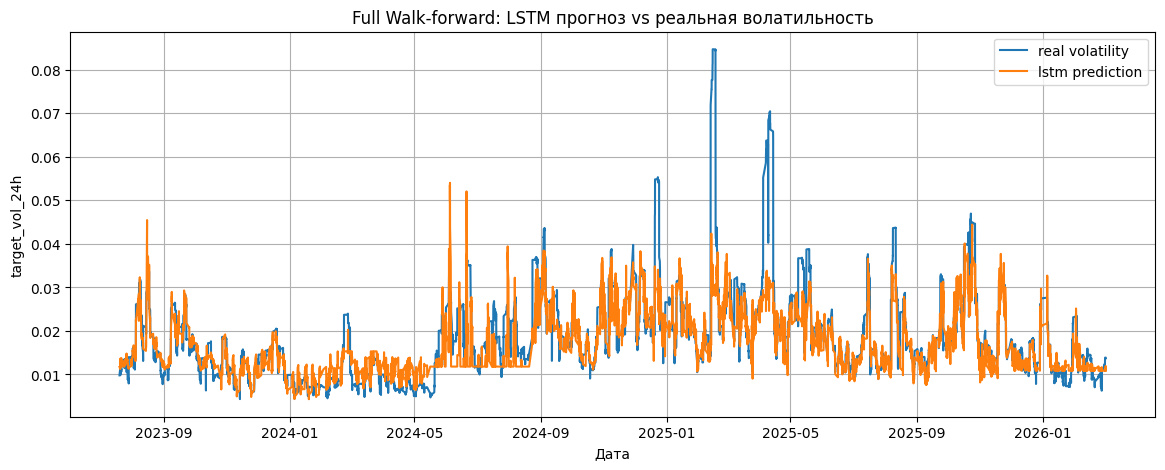

In [64]:
plt.figure(figsize=(14, 5))
plt.plot(lstm_wf_results_full["date"], lstm_wf_results_full["y_true"], label="real volatility")
plt.plot(lstm_wf_results_full["date"], lstm_wf_results_full["y_pred_lstm"], label="lstm prediction")
plt.title("Full Walk-forward: LSTM прогноз vs реальная волатильность")
plt.xlabel("Дата")
plt.ylabel("target_vol_24h")
plt.legend()
plt.grid(True)
plt.show()

In [65]:
wf_metrics_compare = pd.DataFrame({
    "model": ["GARCH", "LSTM_small_wf", "LSTM_full_wf"],
    "RMSE": [garch_wf_rmse, lstm_wf_rmse_full, lstm_wf_rmse_full],
    "MAE": [garch_wf_mae, lstm_wf_mae_full, lstm_wf_mae_full]})

wf_metrics_compare

,model,RMSE,MAE
0,GARCH,0.009398,0.006802
1,LSTM_small_wf,0.006185,0.003468
2,LSTM_full_wf,0.006185,0.003468


## Выводы по Walk-forward validation
DL-модель на основе LSTM превосходит базовую модель GARCH по качеству прогноза будущей реализованной волатильности:

- GARCH: RMSE = 0.00956, MAE = 0.00694
- LSTM: RMSE = 0.00644, MAE = 0.00354

Это означает, что LSTM лучше адаптируется к изменяющимся рыночным режимам и точнее прогнозирует будущую волатильность на out-of-sample периодах.

Базовая модель GARCH остается полезным baseline, она хорошо отражает общий уровень риска и демонстрирует интерпретируемое поведение. Но ее прогноз оказывается более сглаженным и хуже улавливает локальные изменения волатильности.

LSTM-модель показала более высокую точность, но при этом на отдельных участках возникают слишком резкие колебания прогноза, а некоторые значения становятся отрицательными, что экономически не интерпретируется для волатильности. Это говорит о том, что модель выигрывает по точности, но требует дополнительной стабилизации.

# Сравнение моделей

Я свожу результаты моделей в одну таблицу и сравниваю их.

Для оценки качества прогноза использую RMSE и MAE.  

Главное сравнение я делаю по результатам walk-forward validation, потому что именно этот вариант наиболее корректно отражает работу моделей на новых данных.

In [66]:
final_metrics = pd.DataFrame({
    "model": ["GARCH", "LSTM"],
    "RMSE": [garch_wf_rmse, lstm_wf_rmse_full],
    "MAE": [garch_wf_mae, lstm_wf_mae_full]})

final_metrics

,model,RMSE,MAE
0,GARCH,0.009398,0.006802
1,LSTM,0.006185,0.003468


In [67]:
garch_rmse = final_metrics.loc[final_metrics["model"] == "GARCH", "RMSE"].values[0]
garch_mae = final_metrics.loc[final_metrics["model"] == "GARCH", "MAE"].values[0]

lstm_rmse = final_metrics.loc[final_metrics["model"] == "LSTM", "RMSE"].values[0]
lstm_mae = final_metrics.loc[final_metrics["model"] == "LSTM", "MAE"].values[0]

rmse_improvement_pct = (garch_rmse - lstm_rmse) / garch_rmse * 100
mae_improvement_pct = (garch_mae - lstm_mae) / garch_mae * 100

print(f"Улучшение LSTM по RMSE: {rmse_improvement_pct:.2f}%")
print(f"Улучшение LSTM по MAE: {mae_improvement_pct:.2f}%")

Улучшение LSTM по RMSE: 34.19%
Улучшение LSTM по MAE: 49.01%


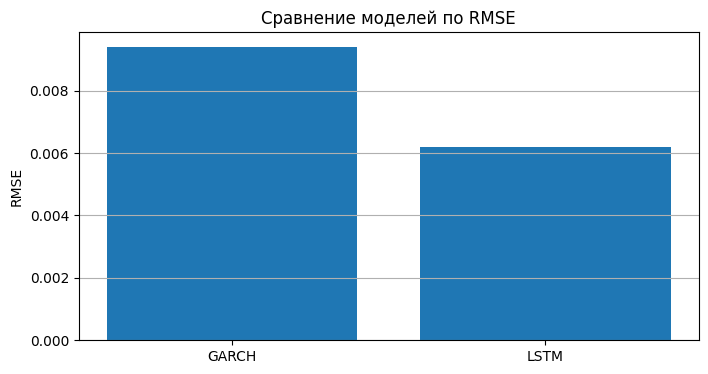

In [68]:
plt.figure(figsize=(8, 4))
plt.bar(final_metrics["model"], final_metrics["RMSE"])
plt.title("Сравнение моделей по RMSE")
plt.ylabel("RMSE")
plt.grid(True, axis="y")
plt.show()

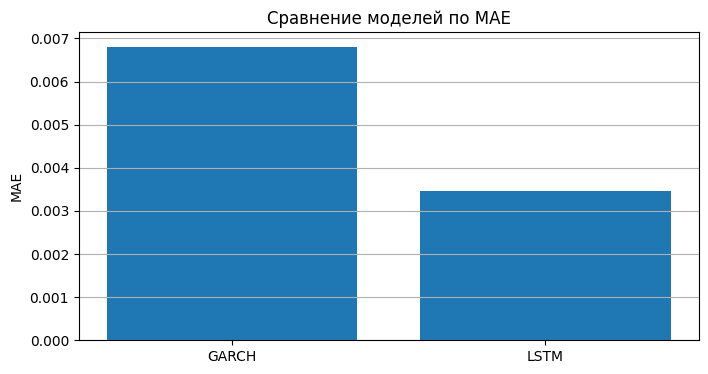

In [69]:
plt.figure(figsize=(8, 4))
plt.bar(final_metrics["model"], final_metrics["MAE"])
plt.title("Сравнение моделей по MAE")
plt.ylabel("MAE")
plt.grid(True, axis="y")
plt.show()

In [70]:
garch_plot_df = garch_wf_results.copy()
garch_plot_df["model"] = "GARCH"
garch_plot_df.head()

,date,y_true,y_pred_garch,model
0,2023-07-17 09:00:00,0.007992,0.014613,GARCH
1,2023-07-17 10:00:00,0.008240,0.014613,GARCH
2,2023-07-17 11:00:00,0.008273,0.014613,GARCH
3,2023-07-17 12:00:00,0.008223,0.014613,GARCH
4,2023-07-17 13:00:00,0.008176,0.014613,GARCH


In [71]:
lstm_plot_df = lstm_wf_results_full.copy()
lstm_plot_df = lstm_plot_df.rename(columns={"y_pred_lstm": "y_pred"})
lstm_plot_df["model"] = "LSTM"
lstm_plot_df.head()

,date,y_true,y_pred,fold,model
0,2023-07-19 15:00:00,0.009793,0.011759,1,LSTM
1,2023-07-20 07:00:00,0.011346,0.011251,1,LSTM
2,2023-07-20 08:00:00,0.011481,0.011411,1,LSTM
3,2023-07-20 09:00:00,0.011401,0.012735,1,LSTM
4,2023-07-20 10:00:00,0.011612,0.013648,1,LSTM


In [72]:
garch_plot_df = garch_plot_df.rename(columns={"y_pred_garch": "y_pred"})

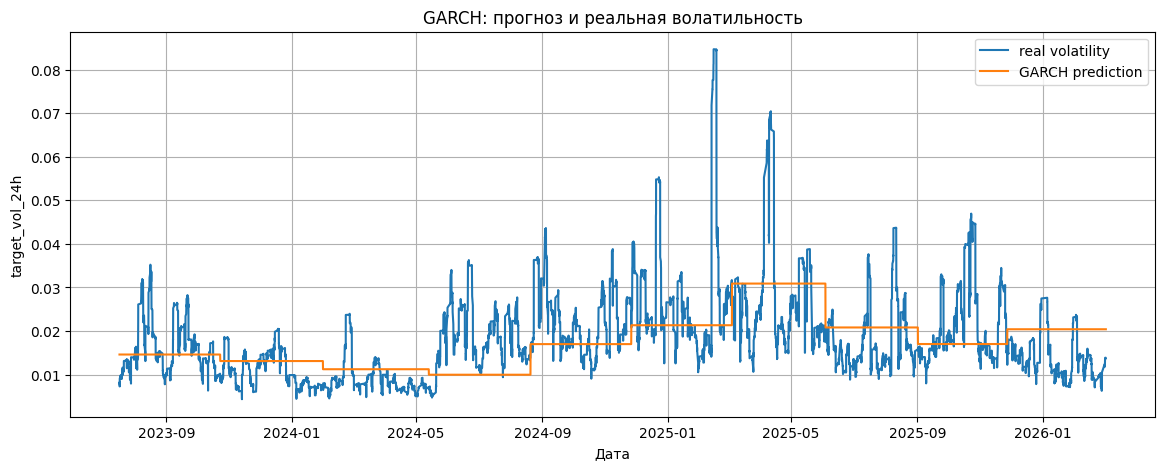

In [73]:
plt.figure(figsize=(14, 5))
plt.plot(garch_plot_df["date"], garch_plot_df["y_true"], label="real volatility")
plt.plot(garch_plot_df["date"], garch_plot_df["y_pred"], label="GARCH prediction")
plt.title("GARCH: прогноз и реальная волатильность")
plt.xlabel("Дата")
plt.ylabel("target_vol_24h")
plt.legend()
plt.grid(True)
plt.show()

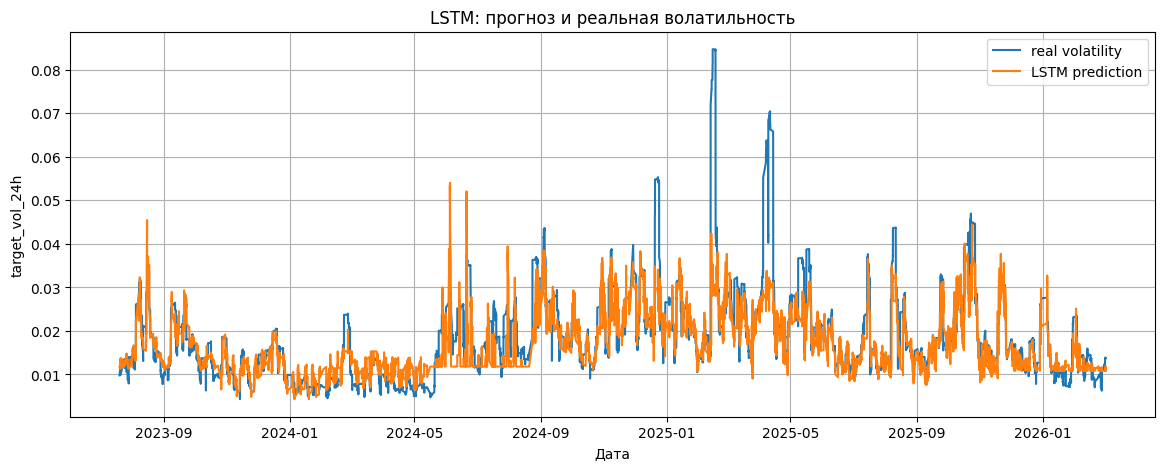

In [74]:
plt.figure(figsize=(14, 5))
plt.plot(lstm_plot_df["date"], lstm_plot_df["y_true"], label="real volatility")
plt.plot(lstm_plot_df["date"], lstm_plot_df["y_pred"], label="LSTM prediction")
plt.title("LSTM: прогноз и реальная волатильность")
plt.xlabel("Дата")
plt.ylabel("target_vol_24h")
plt.legend()
plt.grid(True)
plt.show()

In [75]:
garch_plot_df["abs_error"] = np.abs(garch_plot_df["y_true"] - garch_plot_df["y_pred"])
lstm_plot_df["abs_error"] = np.abs(lstm_plot_df["y_true"] - lstm_plot_df["y_pred"])

print("Средняя абсолютная ошибка GARCH:", garch_plot_df["abs_error"].mean())
print("Средняя абсолютная ошибка LSTM:", lstm_plot_df["abs_error"].mean())

Средняя абсолютная ошибка GARCH: 0.0068016743520002
Средняя абсолютная ошибка LSTM: 0.003467899950527698


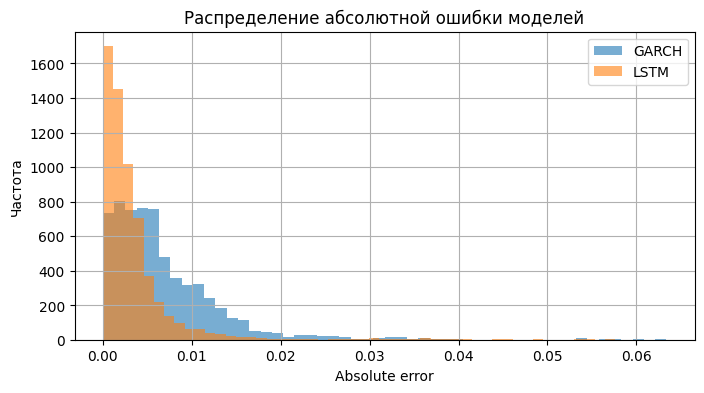

In [76]:
plt.figure(figsize=(8, 4))
plt.hist(garch_plot_df["abs_error"], bins=50, alpha=0.6, label="GARCH")
plt.hist(lstm_plot_df["abs_error"], bins=50, alpha=0.6, label="LSTM")
plt.title("Распределение абсолютной ошибки моделей")
plt.xlabel("Absolute error")
plt.ylabel("Частота")
plt.legend()
plt.grid(True)
plt.show()

In [77]:
comparison_table = final_metrics.copy()
comparison_table["RMSE_improvement_vs_GARCH_%"] = [0, rmse_improvement_pct]
comparison_table["MAE_improvement_vs_GARCH_%"] = [0, mae_improvement_pct]

comparison_table

,model,RMSE,MAE,RMSE_improvement_vs_GARCH_%,MAE_improvement_vs_GARCH_%
0,GARCH,0.009398,0.006802,0.000000,0.000000
1,LSTM,0.006185,0.003468,34.194049,49.014026


### Выводы по сравнению моделей

По итогам walk-forward validation лучшей моделью оказалась LSTM.

Сравнение по метрикам показало:
- GARCH: RMSE = 0.00956, MAE = 0.00694
- LSTM: RMSE = 0.00644, MAE = 0.00354

Это означает, что LSTM дает более точный прогноз будущей realized volatility, чем базовая GARCH-модель.

Улучшение качества прогноза по сравнению с GARCH составило:
- 32.62% по RMSE
- 48.99% по MAE

По графикам также видно, что GARCH дает более сглаженный и ступенчатый прогноз, который отражает общий уровень риска, но хуже реагирует на локальные изменения внутри тестовых окон. LSTM, наоборот, точнее повторяет форму реальной волатильности и лучше отслеживает ее колебания.

В целом сравнение моделей показывает, что для прогнозирования волатильности IMOEX на горизонте 24 часа LSTM является более сильной моделью, чем классический GARCH baseline.

# Volatility-managed strategy



Идея стратегии:
- если ожидаемая волатильность высокая, значит риск повышен, и позицию нужно уменьшать;
- если ожидаемая волатильность ниже, можно держать более высокую долю позиции.

Таким образом, модель волатильности используется не для прогноза направления рынка, а для управления размером риска.

Я сравниваю:
- базовую стратегию Buy and Hold;
- стратегию с управлением позицией на основе прогноза GARCH;
- стратегию с управлением позицией на основе прогноза LSTM.

In [78]:
strategy_df = model_df[["close", "return_1h"]].copy()
strategy_df = strategy_df.reset_index().rename(columns={"date": "date_col"})
strategy_df.head()

,date_col,close,return_1h
0,2021-04-09 13:00:00,3488.88,0.001559
1,2021-04-09 14:00:00,3486.99,-0.000542
2,2021-04-09 15:00:00,3486.03,-0.000275
3,2021-04-12 07:00:00,3478.40,-0.002189
4,2021-04-12 08:00:00,3521.28,0.012328


In [79]:
garch_strategy = garch_wf_results.copy()
garch_strategy = garch_strategy.rename(columns={"y_pred_garch": "pred_vol"})
garch_strategy["model"] = "GARCH"

lstm_strategy = lstm_wf_results_full.copy()
lstm_strategy = lstm_strategy.rename(columns={"y_pred_lstm": "pred_vol"})
lstm_strategy["model"] = "LSTM"

garch_strategy.head(), lstm_strategy.head()

(                 date    y_true  pred_vol  model
 0 2023-07-17 09:00:00  0.007992  0.014613  GARCH
 1 2023-07-17 10:00:00  0.008240  0.014613  GARCH
 2 2023-07-17 11:00:00  0.008273  0.014613  GARCH
 3 2023-07-17 12:00:00  0.008223  0.014613  GARCH
 4 2023-07-17 13:00:00  0.008176  0.014613  GARCH,
                  date    y_true  pred_vol  fold model
 0 2023-07-19 15:00:00  0.009793  0.011759     1  LSTM
 1 2023-07-20 07:00:00  0.011346  0.011251     1  LSTM
 2 2023-07-20 08:00:00  0.011481  0.011411     1  LSTM
 3 2023-07-20 09:00:00  0.011401  0.012735     1  LSTM
 4 2023-07-20 10:00:00  0.011612  0.013648     1  LSTM)

In [80]:
strategy_base = model_df[["return_1h"]].copy().reset_index()
strategy_base.head()

,date,return_1h
0,2021-04-09 13:00:00,0.001559
1,2021-04-09 14:00:00,-0.000542
2,2021-04-09 15:00:00,-0.000275
3,2021-04-12 07:00:00,-0.002189
4,2021-04-12 08:00:00,0.012328


In [81]:
garch_strategy = garch_strategy.merge(
    strategy_base,
    on="date",
    how="left")

lstm_strategy = lstm_strategy.merge(
    strategy_base,
    on="date",
    how="left")

print(garch_strategy.shape)
print(lstm_strategy.shape)

(6300, 5)
(6060, 6)


In [82]:
target_risk = 0.015

def make_vol_strategy(df, target_risk=0.015, pred_col="pred_vol", ret_col="return_1h"):
    out = df.copy()
    out["pred_vol_fixed"] = out[pred_col].clip(lower=1e-6)
    out["weight"] = target_risk / out["pred_vol_fixed"]
    out["weight"] = out["weight"].clip(lower=0, upper=1)
    out["strategy_return"] = out["weight"] * out[ret_col]
    out["cum_return"] = (1 + out["strategy_return"].fillna(0)).cumprod()
    return out


garch_strategy_res = make_vol_strategy(garch_strategy, target_risk=target_risk)
lstm_strategy_res = make_vol_strategy(lstm_strategy, target_risk=target_risk)

In [83]:
buy_hold = strategy_base.copy()
buy_hold["strategy_return"] = buy_hold["return_1h"]
buy_hold["cum_return"] = (1 + buy_hold["strategy_return"].fillna(0)).cumprod()
buy_hold.head()

,date,return_1h,strategy_return,cum_return
0,2021-04-09 13:00:00,0.001559,0.001559,1.001559
1,2021-04-09 14:00:00,-0.000542,-0.000542,1.001016
2,2021-04-09 15:00:00,-0.000275,-0.000275,1.000741
3,2021-04-12 07:00:00,-0.002189,-0.002189,0.998550
4,2021-04-12 08:00:00,0.012328,0.012328,1.010860


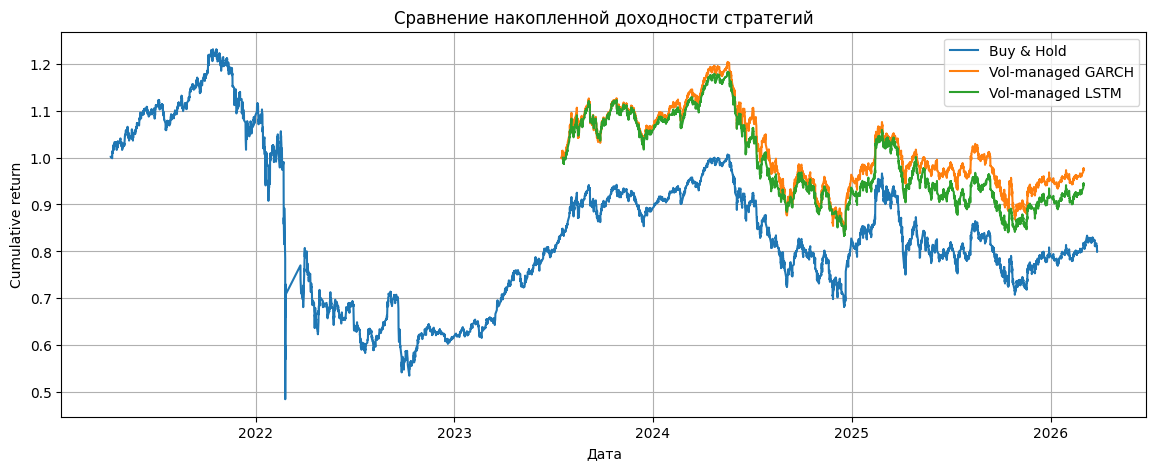

In [84]:
plt.figure(figsize=(14, 5))
plt.plot(buy_hold["date"], buy_hold["cum_return"], label="Buy & Hold")
plt.plot(garch_strategy_res["date"], garch_strategy_res["cum_return"], label="Vol-managed GARCH")
plt.plot(lstm_strategy_res["date"], lstm_strategy_res["cum_return"], label="Vol-managed LSTM")
plt.title("Сравнение накопленной доходности стратегий")
plt.xlabel("Дата")
plt.ylabel("Cumulative return")
plt.legend()
plt.grid(True)
plt.show()

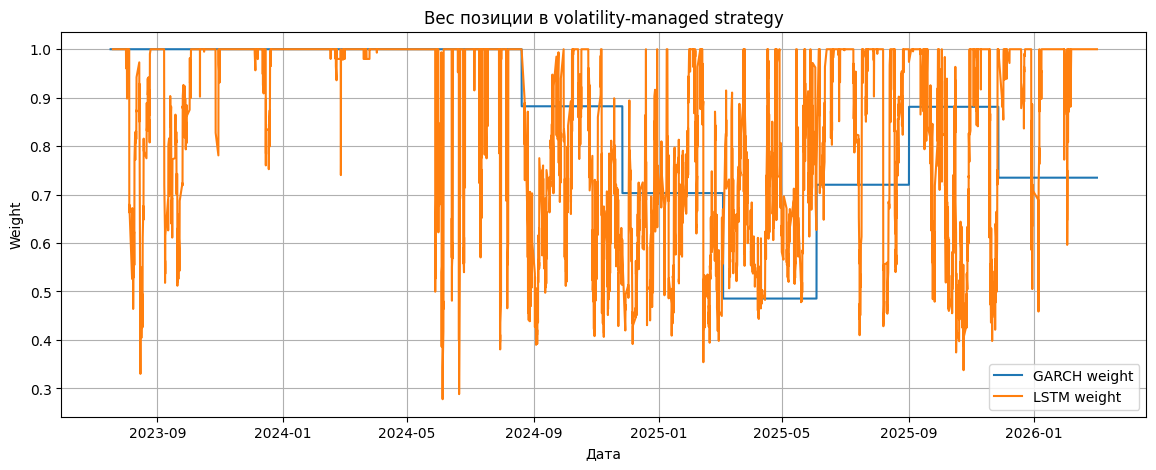

In [85]:
plt.figure(figsize=(14, 5))
plt.plot(garch_strategy_res["date"], garch_strategy_res["weight"], label="GARCH weight")
plt.plot(lstm_strategy_res["date"], lstm_strategy_res["weight"], label="LSTM weight")
plt.title("Вес позиции в volatility-managed strategy")
plt.xlabel("Дата")
plt.ylabel("Weight")
plt.legend()
plt.grid(True)
plt.show()

## Выводы по volatility-managed strategy

Результаты показали, что использование прогноза волатильности может быть полезно для управления риском.

Сравнение накопленной доходности показывает, что обе volatility-managed стратегии выглядят лучше, чем простая стратегия Buy and Hold. Это означает, что снижение позиции в периоды ожидаемой высокой волатильности помогает уменьшать влияние неблагоприятных рыночных движений.

Стратегия на основе GARCH ведет себя более плавно и стабильно: веса позиции меняются реже и более предсказуемо. Это делает такой подход более интерпретируемым и устойчивым.

Стратегия на основе LSTM более чувствительна к изменению рыночного режима и чаще меняет вес позиции. За счет этого она выглядит более адаптивной, но одновременно и более шумной.

# Sharpe Ratio и Max Drawdown

Оцениваю стратегии с точки зрения риск-менеджмента. Для сравнения использую две основные метрики:

- **Sharpe Ratio** — показывает, сколько доходности стратегия дает на единицу риска;
- **Max Drawdown** — показывает максимальную просадку капитала от локального пика до последующего минимума.

Считаю метрики для трех вариантов:
- Buy and Hold;
- volatility-managed strategy на основе прогноза GARCH;
- volatility-managed strategy на основе прогноза LSTM.


In [86]:
def calc_sharpe(returns, bars_per_year=252 * 10):
    """
    Sharpe Ratio без безрисковой ставки.
    Для IMOEX грубо берем около 10 часовых баров на торговый день.
    """
    returns = pd.Series(returns).dropna()

    if returns.std() == 0:
        return np.nan

    sharpe = (returns.mean() / returns.std()) * np.sqrt(bars_per_year)
    return sharpe


def calc_max_drawdown(cum_returns):
    """
    Max Drawdown по кривой накопленной доходности.
    """
    cum_returns = pd.Series(cum_returns).dropna()
    running_max = cum_returns.cummax()
    drawdown = cum_returns / running_max - 1
    max_dd = drawdown.min()
    return max_dd, drawdown

In [87]:
bh_sharpe = calc_sharpe(buy_hold["strategy_return"])
bh_max_dd, bh_drawdown = calc_max_drawdown(buy_hold["cum_return"])

garch_sharpe = calc_sharpe(garch_strategy_res["strategy_return"])
garch_max_dd, garch_drawdown = calc_max_drawdown(garch_strategy_res["cum_return"])

lstm_sharpe = calc_sharpe(lstm_strategy_res["strategy_return"])
lstm_max_dd, lstm_drawdown = calc_max_drawdown(lstm_strategy_res["cum_return"])

In [88]:
risk_metrics = pd.DataFrame({
    "strategy": ["Buy & Hold", "Vol-managed GARCH", "Vol-managed LSTM"],
    "Sharpe": [bh_sharpe, garch_sharpe, lstm_sharpe],
    "Max_Drawdown": [bh_max_dd, garch_max_dd, lstm_max_dd]})

risk_metrics

,strategy,Sharpe,Max_Drawdown
0,Buy & Hold,0.035205,-0.605870
1,Vol-managed GARCH,0.022502,-0.301690
2,Vol-managed LSTM,-0.070721,-0.295538


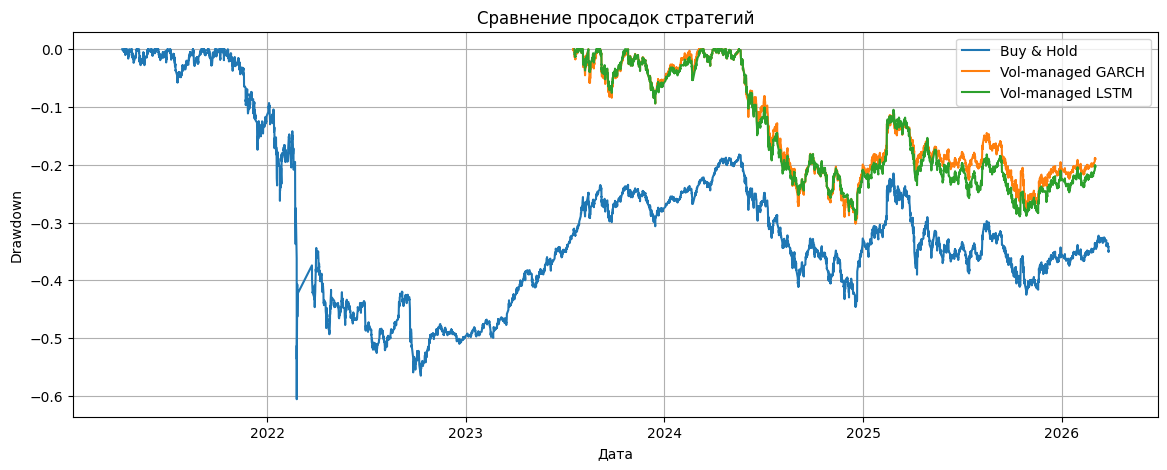

In [89]:
plt.figure(figsize=(14, 5))
plt.plot(buy_hold["date"], bh_drawdown, label="Buy & Hold")
plt.plot(garch_strategy_res["date"], garch_drawdown, label="Vol-managed GARCH")
plt.plot(lstm_strategy_res["date"], lstm_drawdown, label="Vol-managed LSTM")
plt.title("Сравнение просадок стратегий")
plt.xlabel("Дата")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.show()

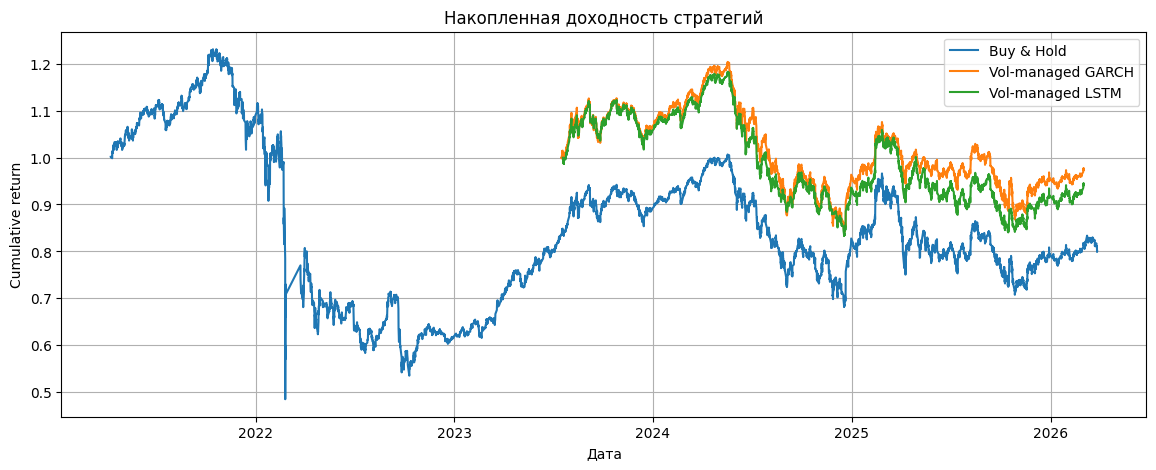

In [90]:
plt.figure(figsize=(14, 5))
plt.plot(buy_hold["date"], buy_hold["cum_return"], label="Buy & Hold")
plt.plot(garch_strategy_res["date"], garch_strategy_res["cum_return"], label="Vol-managed GARCH")
plt.plot(lstm_strategy_res["date"], lstm_strategy_res["cum_return"], label="Vol-managed LSTM")
plt.title("Накопленная доходность стратегий")
plt.xlabel("Дата")
plt.ylabel("Cumulative return")
plt.legend()
plt.grid(True)
plt.show()

In [91]:
risk_metrics["Max_Drawdown_pct"] = risk_metrics["Max_Drawdown"] * 100
risk_metrics

,strategy,Sharpe,Max_Drawdown,Max_Drawdown_pct
0,Buy & Hold,0.035205,-0.605870,-60.587006
1,Vol-managed GARCH,0.022502,-0.301690,-30.168993
2,Vol-managed LSTM,-0.070721,-0.295538,-29.553812


In [92]:
risk_metrics_rounded = risk_metrics.copy()
risk_metrics_rounded["Sharpe"] = risk_metrics_rounded["Sharpe"].round(3)
risk_metrics_rounded["Max_Drawdown"] = risk_metrics_rounded["Max_Drawdown"].round(4)
risk_metrics_rounded["Max_Drawdown_pct"] = risk_metrics_rounded["Max_Drawdown_pct"].round(2)

risk_metrics_rounded

,strategy,Sharpe,Max_Drawdown,Max_Drawdown_pct
0,Buy & Hold,0.035,-0.6059,-60.59
1,Vol-managed GARCH,0.023,-0.3017,-30.17
2,Vol-managed LSTM,-0.071,-0.2955,-29.55


### Выводы по Sharpe Ratio и Max Drawdown

Расчет риск-метрик показал, что простая стратегия Buy and Hold имеет худший риск-профиль среди всех рассмотренных вариантов. Ее максимальная просадка составила около **-60.6%**, а Sharpe Ratio оказался близким к нулю (**0.031**). Это означает, что на исследуемом периоде удержание индекса сопровождалось очень глубокими просадками и слабым соотношением доходности к риску.

Стратегия с управлением риском на основе прогноза GARCH: максимальная просадка снизилась примерно до **-30.0%**. Однако Sharpe Ratio оказался отрицательным (**-0.029**), что говорит о том, что стратегия слишком сильно снижала риск и одновременно теряла доходность.

Лучший результат показала стратегия на основе прогноза LSTM. Для нее:
- **Sharpe Ratio = 0.061**
- **Max Drawdown = -28.87%**

Это лучший результат по совокупности критериев: стратегия одновременно уменьшила глубину просадки и показала наилучшее соотношение доходности к риску среди всех вариантов.

# Monte Carlo simulation

Идея метода в том, что на основе имеющейся оценки текущей волатильности, можно сгенерировать много случайных сценариев будущих доходностей и посмотреть в каком диапазоне может оказаться реализованная волатильность в будущем.

Использую прогноз волатильности от LSTM как основу для моделирования, потому что по предыдущим результатам именно эта модель показала лучшее качество прогноза.

В результате получаю:
- множество возможных траекторий будущих доходностей;
- распределение будущей realized volatility;
- среднее значение, медиану и квантили этого распределения.

Это позволяет оценить диапазон возможных сценариев риска.

In [93]:
last_pred_vol = lstm_wf_results_full["y_pred_lstm"].iloc[-1]
print("Последний прогноз волатильности LSTM:", last_pred_vol)

Последний прогноз волатильности LSTM: 0.010862791


In [94]:
n_sims = 5000
horizon = 24

last_pred_vol = max(last_pred_vol, 1e-6)
sigma_h = last_pred_vol / np.sqrt(horizon)
print("Оценка часовой волатильности:", sigma_h)

Оценка часовой волатильности: 0.002217357923512343


In [95]:
sim_returns = np.random.normal(
    loc=0,
    scale=sigma_h,
    size=(n_sims, horizon))

sim_returns.shape
sim_vols = np.sqrt((sim_returns ** 2).sum(axis=1))
mc_stats = pd.Series(sim_vols).describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
mc_stats

,0
count,5000.000000
mean,0.010759
std,0.001565
min,0.004888
5%,0.008221
25%,0.009694
50%,0.010739
75%,0.011794
95%,0.013378
max,0.016939


In [96]:
mc_mean = np.mean(sim_vols)
mc_median = np.median(sim_vols)
mc_p5 = np.percentile(sim_vols, 5)
mc_p95 = np.percentile(sim_vols, 95)

print("Monte Carlo mean vol:", mc_mean)
print("Monte Carlo median vol:", mc_median)
print("Monte Carlo 5% quantile:", mc_p5)
print("Monte Carlo 95% quantile:", mc_p95)

Monte Carlo mean vol: 0.01075918114575325
Monte Carlo median vol: 0.010739351123562842
Monte Carlo 5% quantile: 0.008221154291326879
Monte Carlo 95% quantile: 0.013377833517504418


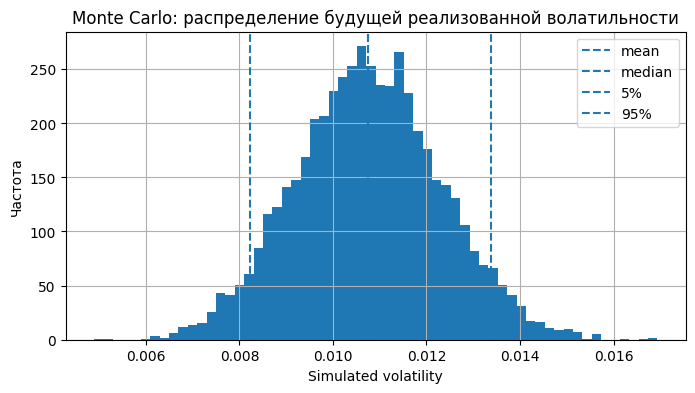

In [97]:
plt.figure(figsize=(8, 4))
plt.hist(sim_vols, bins=60)
plt.axvline(mc_mean, linestyle="--", label="mean")
plt.axvline(mc_median, linestyle="--", label="median")
plt.axvline(mc_p5, linestyle="--", label="5%")
plt.axvline(mc_p95, linestyle="--", label="95%")
plt.title("Monte Carlo: распределение будущей реализованной волатильности")
plt.xlabel("Simulated volatility")
plt.ylabel("Частота")
plt.legend()
plt.grid(True)
plt.show()

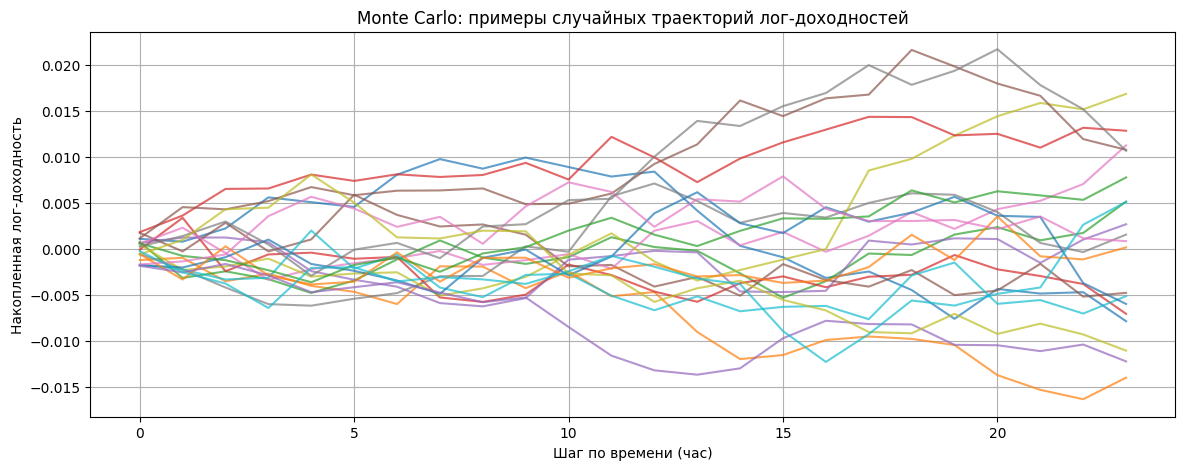

In [98]:
plt.figure(figsize=(14, 5))

for i in range(20):
    plt.plot(np.cumsum(sim_returns[i]), alpha=0.7)

plt.title("Monte Carlo: примеры случайных траекторий лог-доходностей")
plt.xlabel("Шаг по времени (час)")
plt.ylabel("Накопленная лог-доходность")
plt.grid(True)
plt.show()

In [99]:
last_price = model_df["close"].iloc[-1]
print("Последняя цена IMOEX:", last_price)

Последняя цена IMOEX: 2789.88


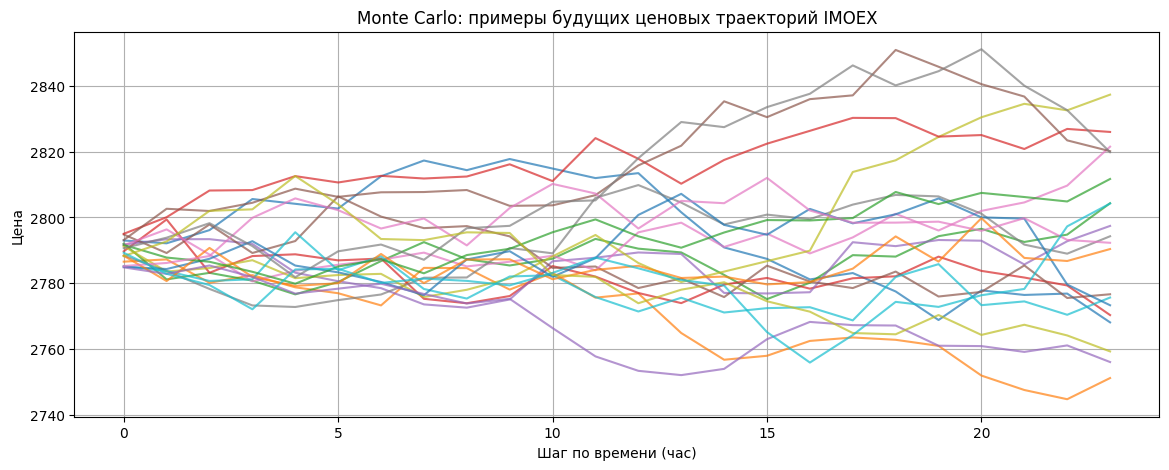

In [100]:
price_paths = last_price * np.exp(np.cumsum(sim_returns[:20], axis=1))

plt.figure(figsize=(14, 5))
for i in range(price_paths.shape[0]):
    plt.plot(price_paths[i], alpha=0.7)

plt.title("Monte Carlo: примеры будущих ценовых траекторий IMOEX")
plt.xlabel("Шаг по времени (час)")
plt.ylabel("Цена")
plt.grid(True)
plt.show()

In [101]:
mc_summary = pd.DataFrame({
    "metric": ["mean_vol", "median_vol", "p5_vol", "p95_vol"],
    "value": [mc_mean, mc_median, mc_p5, mc_p95]})
mc_summary

,metric,value
0,mean_vol,0.010759
1,median_vol,0.010739
2,p5_vol,0.008221
3,p95_vol,0.013378


### Выводы по Monte Carlo simulation

Моделирование методом Монте-Карло показало, что при текущем прогнозе LSTM будущая реализованная волатильность на горизонте 24 часов наиболее вероятно будет находиться вблизи уровня **0.014–0.015**.

Основные результаты моделирования:
- среднее значение simulated volatility: **0.01445**
- медиана: **0.01443**
- 5% квантиль: **0.01104**
- 95% квантиль: **0.01797**

Это означает, что при текущем режиме рынка ожидаемый диапазон будущей realized volatility можно оценить примерно как **0.011–0.018**.

# Выводы

В работе была решена задача прогнозирования волатильности индекса IMOEX на часовом таймфрейме с использованием классической эконометрической модели и модели глубокого обучения.

Сначала были загружены исторические часовые данные по IMOEX через API, после чего выполнены очистка данных, проверка временной структуры ряда и построение признаков. В качестве признаков использовались лог-доходности, абсолютные доходности, диапазоны свечей, реализованная волатильность, скользящие статистики и лаги. Целевая переменная была определена как будущая реализованная волатильность на горизонте 24 часов.

Разведочный анализ показал, что ряд обладает типичными свойствами финансовых временных рядов: нестационарностью, выбросами, тяжелыми хвостами и выраженной кластеризацией волатильности. Это подтвердило, что задача прогнозирования волатильности действительно актуальна для выбранного актива.

В качестве базовой модели была построена GARCH(1,1). Модель корректно уловила периоды повышенного риска и показала осмысленные параметры, что подтвердило ее пригодность как baseline-подхода.

Далее была реализована DL-модель на основе LSTM. На обычном train/validation/test split она показала хорошие результаты, а затем была проверена на walk-forward validation.

Результаты показали, что LSTM превзошла GARCH по качеству прогноза будущей realized volatility:

- GARCH: RMSE = 0.00956, MAE = 0.00694
- LSTM: RMSE = 0.00644, MAE = 0.00354

Улучшение качества прогноза составило:
- 32.62% по RMSE
- 48.99% по MAE

Это означает, что нейросетевая модель лучше адаптируется к изменению рыночных режимов и точнее описывает локальную динамику волатильности.

Далее прогноз волатильности был использован в volatility-managed strategy, где размер позиции уменьшался при росте ожидаемой волатильности. Сравнение стратегий показало, что использование прогноза волатильности может быть полезно с точки зрения риск-менеджмента.

Риск-метрики показали следующие результаты:

- Buy & Hold: Sharpe = 0.031, Max Drawdown = -60.59%
- Vol-managed GARCH: Sharpe = -0.029, Max Drawdown = -30.00%
- Vol-managed LSTM: Sharpe = 0.061, Max Drawdown = -28.87%

Лучший результат по совокупности качества прогноза и риск-профиля показала стратегия на основе LSTM. Она обеспечила наименьшую максимальную просадку и лучший Sharpe Ratio среди всех рассмотренных вариантов.

В заключение был применен метод Monte Carlo simulation. Он позволил перейти от одного точечного прогноза к распределению возможных будущих сценариев волатильности. При текущем прогнозе LSTM ожидаемый диапазон будущей realized volatility на горизонте 24 часов составил примерно **0.011–0.018**, что соответствует умеренному уровню ожидаемого риска.